In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/odins0n/amex-parquet/test_data.parquet
/kaggle/input/datasets/odins0n/amex-parquet/train_data.parquet


In [3]:
import pandas as pd
import pyarrow.parquet as pq

TRAIN_PATH = "/kaggle/input/datasets/odins0n/amex-parquet/train_data.parquet"

# Inspect Parquet metadata without loading the dataset
parquet_file = pq.ParquetFile(TRAIN_PATH)

print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of columns:", parquet_file.metadata.num_columns)
print("Number of row groups:", parquet_file.num_row_groups)

Number of rows: 5531451
Number of columns: 192
Number of row groups: 1


In [4]:
# Inspect column names and data types without loading the full dataset

schema = parquet_file.schema_arrow

schema_df = pd.DataFrame({
    "column": schema.names,
    "dtype": [str(field.type) for field in schema]
})

print(schema_df.to_string(index=False))

           column  dtype
      customer_ID string
              S_2 string
              P_2  float
             D_39  float
              B_1  float
              B_2  float
              R_1  float
              S_3  float
             D_41  float
              B_3  float
             D_42  float
             D_43  float
             D_44  float
              B_4  float
             D_45  float
              B_5  float
              R_2  float
             D_46  float
             D_47  float
             D_48  float
             D_49  float
              B_6  float
              B_7  float
              B_8  float
             D_50  float
             D_51  float
              B_9  float
              R_3  float
             D_52  float
              P_3  float
             B_10  float
             D_53  float
              S_5  float
             B_11  float
              S_6  float
             D_54  float
              R_4  float
              S_7  float
             B_12  float


In [5]:
import pyarrow as pa

# Process the Parquet file in manageable batches
batch_size = 100_000

total_rows = 0
unique_customers = set()
unique_dates = set()

target_by_customer = {}
customer_row_counts = {}

for batch in pq.ParquetFile(TRAIN_PATH).iter_batches(
    batch_size=batch_size,
    columns=["customer_ID", "S_2", "target", "index_level_0"]
):
    
    df_batch = batch.to_pandas()
    
    total_rows += len(df_batch)
    
    # Unique customers
    unique_customers.update(df_batch["customer_ID"].unique())
    
    # Unique statement dates
    unique_dates.update(df_batch["S_2"].unique())
    
    # Number of observations per customer
    counts = df_batch["customer_ID"].value_counts()
    for customer, count in counts.items():
        customer_row_counts[customer] = (
            customer_row_counts.get(customer, 0) + count
        )
    
    # Target consistency within customer
    grouped_target = df_batch.groupby("customer_ID")["target"].nunique()
    inconsistent = grouped_target[grouped_target > 1]
    
    if len(inconsistent) > 0:
        print("WARNING: Target inconsistency detected within batch.")

print("Total rows:", total_rows)
print("Unique customers:", len(unique_customers))
print("Unique statement dates:", len(unique_dates))
print("Target inconsistencies detected:", len(inconsistent))

Total rows: 5531451
Unique customers: 458913
Unique statement dates: 396
Target inconsistencies detected: 0


In [6]:
import numpy as np
from collections import defaultdict

customer_counts = defaultdict(int)
customer_target_min = {}
customer_target_max = {}

min_date = None
max_date = None

for batch in pq.ParquetFile(TRAIN_PATH).iter_batches(
    batch_size=100_000,
    columns=["customer_ID", "S_2", "target"]
):
    
    df_batch = batch.to_pandas()

    # Number of observations per customer
    counts = df_batch["customer_ID"].value_counts()

    for customer, count in counts.items():
        customer_counts[customer] += int(count)

    # Target consistency
    grouped = df_batch.groupby("customer_ID")["target"].agg(["min", "max"])

    for customer, row in grouped.iterrows():
        if customer not in customer_target_min:
            customer_target_min[customer] = row["min"]
            customer_target_max[customer] = row["max"]
        else:
            customer_target_min[customer] = min(
                customer_target_min[customer], row["min"]
            )
            customer_target_max[customer] = max(
                customer_target_max[customer], row["max"]
            )

    # Date range
    batch_dates = pd.to_datetime(df_batch["S_2"])

    batch_min = batch_dates.min()
    batch_max = batch_dates.max()

    if min_date is None or batch_min < min_date:
        min_date = batch_min

    if max_date is None or batch_max > max_date:
        max_date = batch_max


# Convert customer observation counts to Series
customer_counts = pd.Series(customer_counts)

# Check global target consistency
target_inconsistent = sum(
    customer_target_min[c] != customer_target_max[c]
    for c in customer_target_min
)

# Target prevalence
customer_targets = pd.Series(customer_target_max)

print("===== CUSTOMER STRUCTURE =====")
print("Unique customers:", len(customer_counts))
print("Minimum observations/customer:", customer_counts.min())
print("Maximum observations/customer:", customer_counts.max())
print("Mean observations/customer:", customer_counts.mean())

print("\n===== OBSERVATION COUNT DISTRIBUTION =====")
print(customer_counts.value_counts().sort_index())

print("\n===== TARGET =====")
print("Target inconsistencies:", target_inconsistent)
print("\nCustomer-level target distribution:")
print(customer_targets.value_counts())
print("\nCustomer-level default rate:")
print(customer_targets.mean())

print("\n===== DATE RANGE =====")
print("Earliest statement date:", min_date)
print("Latest statement date:", max_date)

===== CUSTOMER STRUCTURE =====
Unique customers: 458913
Minimum observations/customer: 1
Maximum observations/customer: 13
Mean observations/customer: 12.053376130116165

===== OBSERVATION COUNT DISTRIBUTION =====
1       5120
2       6098
3       5778
4       4673
5       4671
6       5515
7       5198
8       6110
9       6411
10      6721
11      5961
12     10623
13    386034
Name: count, dtype: int64

===== TARGET =====
Target inconsistencies: 0

Customer-level target distribution:
0    340085
1    118828
Name: count, dtype: int64

Customer-level default rate:
0.2589336105100531

===== DATE RANGE =====
Earliest statement date: 2017-03-01 00:00:00
Latest statement date: 2018-03-31 00:00:00


In [8]:
# Analyze the temporal structure of customer histories

date_history = {}

for batch in pq.ParquetFile(TRAIN_PATH).iter_batches(
    batch_size=100_000,
    columns=["customer_ID", "S_2"]
):
    batch_df = batch.to_pandas()
    
    batch_df["S_2"] = pd.to_datetime(batch_df["S_2"])
    
    for customer, dates in batch_df.groupby("customer_ID")["S_2"]:
        if customer not in date_history:
            date_history[customer] = []
        
        date_history[customer].extend(dates.tolist())


# Create summary dataframe
history_df = pd.DataFrame({
    "customer_ID": list(date_history.keys()),
    "n_statements": [len(v) for v in date_history.values()],
    "first_statement": [min(v) for v in date_history.values()],
    "last_statement": [max(v) for v in date_history.values()]
})

print("===== HISTORY COMPLETENESS =====")
print(history_df["n_statements"].describe())

print("\n===== FIRST STATEMENT DATE =====")
print(history_df["first_statement"].describe())

print("\n===== LAST STATEMENT DATE =====")
print(history_df["last_statement"].describe())

print("\n===== HISTORY LENGTH =====")
print(history_df["n_statements"].value_counts().sort_index())

===== HISTORY COMPLETENESS =====
count    458913.000000
mean         12.053376
std           2.610273
min           1.000000
25%          13.000000
50%          13.000000
75%          13.000000
max          13.000000
Name: n_statements, dtype: float64

===== FIRST STATEMENT DATE =====
count                           458913
mean     2017-04-13 01:05:18.672166656
min                2017-03-01 00:00:00
25%                2017-03-11 00:00:00
50%                2017-03-19 00:00:00
75%                2017-03-28 00:00:00
max                2018-03-31 00:00:00
Name: first_statement, dtype: object

===== LAST STATEMENT DATE =====
count                           458913
mean     2018-03-16 11:24:57.483836928
min                2018-03-01 00:00:00
25%                2018-03-10 00:00:00
50%                2018-03-17 00:00:00
75%                2018-03-24 00:00:00
max                2018-03-31 00:00:00
Name: last_statement, dtype: object

===== HISTORY LENGTH =====
n_statements
1       5120
2       

In [9]:
del date_history

In [10]:
# Check whether customer statement dates follow a monthly pattern

gap_counts = []

for batch in pq.ParquetFile(TRAIN_PATH).iter_batches(
    batch_size=100_000,
    columns=["customer_ID", "S_2"]
):
    batch_df = batch.to_pandas()
    batch_df["S_2"] = pd.to_datetime(batch_df["S_2"])

    for customer, dates in batch_df.groupby("customer_ID")["S_2"]:
        dates = dates.sort_values().drop_duplicates()

        if len(dates) > 1:
            # Difference between consecutive statements in days
            gaps = dates.diff().dt.days.dropna()
            gap_counts.extend(gaps.tolist())

gap_series = pd.Series(gap_counts)

print("===== STATEMENT DATE GAPS =====")
print(gap_series.describe())

print("\n===== COMMON GAPS =====")
print(gap_series.value_counts().head(20).sort_index())

print("\n===== GAP DISTRIBUTION =====")
print("Gaps <= 31 days:", (gap_series <= 31).mean())
print("Gaps 28-31 days:", gap_series.between(28, 31).mean())
print("Gaps > 31 days:", (gap_series > 31).mean())

===== STATEMENT DATE GAPS =====
count    5.072485e+06
mean     3.052735e+01
std      1.153553e+01
min      1.000000e+00
25%      2.500000e+01
50%      3.100000e+01
75%      3.600000e+01
max      3.920000e+02
dtype: float64

===== COMMON GAPS =====
21.0     86920
22.0     86361
23.0     90388
24.0     94671
25.0     98430
26.0    102790
27.0    109303
28.0    254319
29.0    171925
30.0    553042
31.0    765640
32.0    215629
33.0    113358
34.0    107862
35.0    109577
36.0    100090
37.0     94908
38.0     89880
39.0     85796
40.0     82409
Name: count, dtype: int64

===== GAP DISTRIBUTION =====
Gaps <= 31 days: 0.6402140173898987
Gaps 28-31 days: 0.34399825726443745
Gaps > 31 days: 0.35978598261010136


**Phase 1 — Create development sample**

In [11]:
import pandas as pd
import pyarrow.parquet as pq

TRAIN_PATH = "/kaggle/input/datasets/odins0n/amex-parquet/train_data.parquet"

# Read ONLY customer_ID
customer_id_table = pq.read_table(
    TRAIN_PATH,
    columns=["customer_ID"]
)

customer_ids = pd.Series(
    customer_id_table["customer_ID"].to_pandas().unique(),
    name="customer_ID"
)

print("Total unique customers:", len(customer_ids))
print("First 5 customer IDs:")
print(customer_ids.head())

Total unique customers: 458913
First 5 customer IDs:
0    0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...
1    00000fd6641609c6ece5454664794f0340ad84dddce9a2...
2    00001b22f846c82c51f6e3958ccd81970162bae8b007e8...
3    000041bdba6ecadd89a52d11886e8eaaec9325906c9723...
4    00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...
Name: customer_ID, dtype: object


In [12]:
RANDOM_STATE = 42
N_CUSTOMERS = 50_000

sample_customer_ids = customer_ids.sample(
    n=N_CUSTOMERS,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Selected customers:", len(sample_customer_ids))
print("\nFirst 10 sampled customer IDs:")
print(sample_customer_ids.head(10))

Selected customers: 50000

First 10 sampled customer IDs:
0    12c761e40348fa242de0356426fa9547f0feea34d1f57b...
1    c34b0cf3175108892e42e9382e8177847ac15636870604...
2    14aff3c0e0ed2aaaef6deb127f2541b67fdd0002615bfd...
3    f82be644eb90ab65d737b6dfc5de670559fa2ca23c98ea...
4    09dec6d53f0f12db6edcaecbb4d2bddf41f220ba9569d1...
5    39840356aced228bdd231133902476a13ee94583a2af2b...
6    a18c0fcc8b2d312dc813bfaaa3670a490df4ebcdc61d9e...
7    f9a7295785ac43838cf0ed291a4f7e661a458cc5726f83...
8    422271c20b6d4b6cec933866703dfd0b7cd7f7d566cdaf...
9    a8a398aaae19e78a2e9f21c8445ea16ade997c2c143797...
Name: customer_ID, dtype: object


In [13]:
# Convert sampled IDs into a Python set for fast membership checking
sample_customer_set = set(sample_customer_ids)

# Read the dataset in batches and keep only sampled customers
sample_batches = []

for batch in pq.ParquetFile(TRAIN_PATH).iter_batches(
    batch_size=250_000
):
    batch_df = batch.to_pandas()

    mask = batch_df["customer_ID"].isin(sample_customer_set)

    if mask.any():
        sample_batches.append(batch_df.loc[mask])

# Combine all selected customer records
dev_df = pd.concat(sample_batches, ignore_index=True)

print("Development dataset shape:", dev_df.shape)
print("Unique customers:", dev_df["customer_ID"].nunique())
print("Total observations:", len(dev_df))

Development dataset shape: (603564, 191)
Unique customers: 50000
Total observations: 603564


In [14]:
# Compare development sample columns with the original schema
# Validate the samples

original_columns = set(schema.names)
dev_columns = set(dev_df.columns)

missing_columns = original_columns - dev_columns
extra_columns = dev_columns - original_columns

print("Original columns:", len(original_columns))
print("Development columns:", len(dev_columns))

print("\nMissing columns from development dataset:")
print(missing_columns)

print("\nExtra columns in development dataset:")
print(extra_columns)

print("\nUnique customers:", dev_df["customer_ID"].nunique())
print("Rows:", len(dev_df))

print("\nTarget distribution:")
print(dev_df["target"].value_counts())

Original columns: 192
Development columns: 191

Missing columns from development dataset:
{'__index_level_0__'}

Extra columns in development dataset:
set()

Unique customers: 50000
Rows: 603564

Target distribution:
target
0    456351
1    147213
Name: count, dtype: int64


In [15]:
dev_customer_target = (
    dev_df[["customer_ID", "target"]]
    .drop_duplicates()
)

print("Customer-level sample shape:", dev_customer_target.shape)

print("\nCustomer-level target distribution:")
print(dev_customer_target["target"].value_counts())

print("\nCustomer-level target proportion:")
print(dev_customer_target["target"].value_counts(normalize=True))

Customer-level sample shape: (50000, 2)

Customer-level target distribution:
target
0    37288
1    12712
Name: count, dtype: int64

Customer-level target proportion:
target
0    0.74576
1    0.25424
Name: proportion, dtype: float64


In [16]:
# verify the history-length distribution
dev_history = (
    dev_df.groupby("customer_ID")
    .size()
)

print("===== SAMPLE HISTORY CHECK =====")
print("Customers:", dev_history.shape[0])
print("Minimum statements:", dev_history.min())
print("Maximum statements:", dev_history.max())
print("Mean statements:", dev_history.mean())

print("\nStatements per customer:")
print(dev_history.value_counts().sort_index())

print("\nProportion with 13 statements:")
print((dev_history == 13).mean())

===== SAMPLE HISTORY CHECK =====
Customers: 50000
Minimum statements: 1
Maximum statements: 13
Mean statements: 12.07128

Statements per customer:
1       524
2       662
3       637
4       491
5       516
6       607
7       570
8       596
9       702
10      719
11      628
12     1079
13    42269
Name: count, dtype: int64

Proportion with 13 statements:
0.84538


In [17]:
DEV_PATH = "/kaggle/working/amex_dev_50k.parquet"

dev_df.to_parquet(
    DEV_PATH,
    index=False
)

print("Saved:", DEV_PATH)
print("Shape:", dev_df.shape)

Saved: /kaggle/working/amex_dev_50k.parquet
Shape: (603564, 191)


**Phase 2 — EDA**

*EDA 1 — Data Quality Audit*

In [18]:
import pandas as pd
import numpy as np

DEV_PATH = "/kaggle/working/amex_dev_50k.parquet"

dev_df = pd.read_parquet(DEV_PATH)

print("Shape:", dev_df.shape)
print("Memory usage:", round(dev_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

Shape: (603564, 191)
Memory usage: 591.72 MB


In [19]:
print("===== BASIC DATA AUDIT =====")

print("\nShape:")
print(dev_df.shape)

print("\nData types:")
print(dev_df.dtypes.value_counts())

print("\nMissing values — total:")
print(dev_df.isna().sum().sum())

print("\nDuplicate complete rows:")
print(dev_df.duplicated().sum())

print("\nUnique customers:")
print(dev_df["customer_ID"].nunique())

print("\nUnique statement dates:")
print(dev_df["S_2"].nunique())

print("\nTarget values:")
print(dev_df["target"].value_counts())

===== BASIC DATA AUDIT =====

Shape:
(603564, 191)

Data types:
float32    185
object       4
int64        2
Name: count, dtype: int64

Missing values — total:
17550511

Duplicate complete rows:
0

Unique customers:
50000

Unique statement dates:
396

Target values:
target
0    456351
1    147213
Name: count, dtype: int64


In [20]:
# Check for duplicate customer + statement-date combinations

customer_date_duplicates = dev_df.duplicated(
    subset=["customer_ID", "S_2"]
).sum()

print("Duplicate customer-statement records:", customer_date_duplicates)

# If duplicates exist, show how many customers are affected
if customer_date_duplicates > 0:
    duplicate_records = dev_df[
        dev_df.duplicated(
            subset=["customer_ID", "S_2"],
            keep=False
        )
    ]

    print(
        "Customers affected:",
        duplicate_records["customer_ID"].nunique()
    )

Duplicate customer-statement records: 0


*EDA 2 — Missingness*

In [21]:
# Missing-value profile by feature

missing_summary = pd.DataFrame({
    "missing_count": dev_df.isna().sum(),
    "missing_pct": dev_df.isna().mean() * 100,
    "dtype": dev_df.dtypes.astype(str)
})

missing_summary = (
    missing_summary
    .sort_values("missing_pct", ascending=False)
)

print("===== TOP 30 FEATURES BY MISSINGNESS =====")
print(missing_summary.head(30).to_string())

print("\n===== MISSINGNESS SUMMARY =====")
print("Features with any missing values:",
      (missing_summary["missing_count"] > 0).sum())

print("Features with >50% missing:",
      (missing_summary["missing_pct"] > 50).sum())

print("Features with >90% missing:",
      (missing_summary["missing_pct"] > 90).sum())

print("Features with 0% missing:",
      (missing_summary["missing_pct"] == 0).sum())

===== TOP 30 FEATURES BY MISSINGNESS =====
       missing_count  missing_pct    dtype
D_87          603085    99.920638  float32
D_88          602938    99.896283  float32
D_108         600512    99.494337  float32
D_110         599910    99.394596  float32
D_111         599910    99.394596  float32
B_39          599627    99.347708  float32
D_73          597278    98.958520  float32
B_42          595604    98.681167  float32
D_138         583430    96.664148  float32
D_136         583430    96.664148  float32
D_135         583430    96.664148  float32
D_134         583430    96.664148  float32
D_137         583430    96.664148  float32
R_9           570236    94.478133  float32
B_29          562704    93.230213  float32
D_106         545508    90.381136  float32
D_132         545340    90.353301  float32
D_49          545006    90.297963  float32
R_26          538390    89.201808  float32
D_66          536330    88.860502  float32
D_76          535136    88.662677  float32
D_42       

In [22]:
# Analyze whether missingness is associated with default

high_missing_features = missing_summary[
    missing_summary["missing_pct"] > 50
].index.tolist()

missing_target_results = []

for feature in high_missing_features:
    
    missing_mask = dev_df[feature].isna()
    
    # Row-level default rate conditional on missingness
    missing_default_rate = dev_df.loc[
        missing_mask, "target"
    ].mean()
    
    observed_default_rate = dev_df.loc[
        ~missing_mask, "target"
    ].mean()
    
    missing_target_results.append({
        "feature": feature,
        "missing_pct": missing_mask.mean() * 100,
        "default_rate_missing": missing_default_rate * 100,
        "default_rate_observed": observed_default_rate * 100,
        "difference_pp": (
            missing_default_rate - observed_default_rate
        ) * 100
    })

missing_target_df = pd.DataFrame(
    missing_target_results
).sort_values(
    "difference_pp",
    key=abs,
    ascending=False
)

print(
    missing_target_df.to_string(index=False)
)

feature  missing_pct  default_rate_missing  default_rate_observed  difference_pp
   D_87    99.920638             24.344164              82.881002     -58.536838
   D_88    99.896283             24.332518              80.351438     -56.018919
   R_26    89.201808             20.393767              57.407862     -37.014095
  D_135    96.664148             23.186501              59.282805     -36.096305
  D_138    96.664148             23.186501              59.282805     -36.096305
  D_134    96.664148             23.186501              59.282805     -36.096305
  D_137    96.664148             23.186501              59.282805     -36.096305
  D_136    96.664148             23.186501              59.282805     -36.096305
    R_9    94.478133             22.483498              57.021123     -34.537625
   D_49    90.297963             21.205638              54.033608     -32.827970
  D_106    90.381136             21.233419              54.056428     -32.823009
  D_132    90.353301        

In [23]:
# Customer-level missingness analysis
# Start with the highly-missing features (>50%)

high_missing_features = missing_summary[
    missing_summary["missing_pct"] > 50
].index.tolist()

customer_missing_results = []

for feature in high_missing_features:

    # Missing proportion across each customer's available statements
    customer_missing_pct = (
        dev_df.groupby("customer_ID")[feature]
        .apply(lambda x: x.isna().mean() * 100)
    )

    # Attach customer-level target
    customer_target = (
        dev_df[["customer_ID", "target"]]
        .drop_duplicates("customer_ID")
        .set_index("customer_ID")["target"]
    )

    temp = pd.DataFrame({
        "missing_pct": customer_missing_pct,
        "target": customer_target
    })

    # Categorize missingness
    temp["missing_group"] = pd.cut(
        temp["missing_pct"],
        bins=[-0.001, 0, 50, 99.999, 100.001],
        labels=[
            "Always observed",
            "Partially missing",
            "Mostly missing",
            "Always missing"
        ]
    )

    for group, group_df in temp.groupby(
        "missing_group",
        observed=True
    ):
        customer_missing_results.append({
            "feature": feature,
            "missing_group": str(group),
            "customers": len(group_df),
            "default_rate": group_df["target"].mean() * 100
        })

customer_missing_df = pd.DataFrame(customer_missing_results)

print(customer_missing_df.head(30).to_string(index=False))

feature     missing_group  customers  default_rate
   D_87 Partially missing         40     85.000000
   D_87    Mostly missing         54     87.037037
   D_87    Always missing      49906     25.309582
   D_88 Partially missing          7     57.142857
   D_88    Mostly missing        253     81.027668
   D_88    Always missing      49740     25.136711
  D_108   Always observed          2    100.000000
  D_108 Partially missing         16     68.750000
  D_108    Mostly missing       2218     41.298467
  D_108    Always missing      47764     24.669207
  D_110   Always observed         92     53.260870
  D_110 Partially missing        204     55.392157
  D_110    Mostly missing        170     45.294118
  D_110    Always missing      49534     25.180684
  D_111   Always observed         92     53.260870
  D_111 Partially missing        204     55.392157
  D_111    Mostly missing        170     45.294118
  D_111    Always missing      49534     25.180684
   B_39   Always observed      

In [24]:
# EDA 2 — Final Customer-Level Missingness Summary


# Features with any missing values
missing_features = [
    col for col in dev_df.columns
    if dev_df[col].isna().any()
]

# Customer-level target
customer_target = (
    dev_df[["customer_ID", "target"]]
    .drop_duplicates("customer_ID")
    .set_index("customer_ID")["target"]
)

missingness_results = []

for feature in missing_features:

    # Percentage of statements missing for each customer
    customer_missing_rate = (
        dev_df.groupby("customer_ID")[feature]
        .apply(lambda x: x.isna().mean())
    )

    # Combine missingness with customer-level target
    temp = pd.DataFrame({
        "missing_rate": customer_missing_rate,
        "target": customer_target
    })

    # Customer-level missingness categories
    always_observed = temp["missing_rate"] == 0
    always_missing = temp["missing_rate"] == 1
    observed_at_least_once = temp["missing_rate"] < 1
    missing_at_least_once = temp["missing_rate"] > 0

    # Default rates
    default_always_observed = (
        temp.loc[always_observed, "target"].mean()
        if always_observed.sum() > 0 else np.nan
    )

    default_always_missing = (
        temp.loc[always_missing, "target"].mean()
        if always_missing.sum() > 0 else np.nan
    )

    default_observed_once = (
        temp.loc[observed_at_least_once, "target"].mean()
        if observed_at_least_once.sum() > 0 else np.nan
    )

    # Difference between always-missing and observed-at-least-once
    difference_pp = (
        default_observed_once - default_always_missing
    ) * 100

    missingness_results.append({
        "feature": feature,

        # Overall statement-level missingness
        "missing_pct_rows": dev_df[feature].isna().mean() * 100,

        # Customer-level counts
        "customers_always_missing": int(always_missing.sum()),
        "customers_observed_once_plus": int(observed_at_least_once.sum()),

        # Additional useful count
        "customers_always_observed": int(always_observed.sum()),

        # Default rates
        "default_rate_always_missing": default_always_missing * 100,
        "default_rate_observed_once_plus": default_observed_once * 100,
        "default_rate_always_observed": default_always_observed * 100,

        # Main missingness signal
        "missingness_difference_pp": difference_pp
    })


missingness_final = pd.DataFrame(missingness_results)

# Rank by absolute difference
missingness_final["abs_difference_pp"] = (
    missingness_final["missingness_difference_pp"].abs()
)

missingness_final = (
    missingness_final
    .sort_values(
        "abs_difference_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display
print("===== FINAL CUSTOMER-LEVEL MISSINGNESS TABLE =====")
print(
    missingness_final.to_string(index=False)
)

===== FINAL CUSTOMER-LEVEL MISSINGNESS TABLE =====
feature  missing_pct_rows  customers_always_missing  customers_observed_once_plus  customers_always_observed  default_rate_always_missing  default_rate_observed_once_plus  default_rate_always_observed  missingness_difference_pp  abs_difference_pp
   D_87         99.920638                     49906                            94                          0                    25.309582                        86.170213                           NaN                  60.860631          60.860631
   D_88         99.896283                     49740                           260                          0                    25.136711                        80.384615                           NaN                  55.247904          55.247904
   R_26         89.201808                     44548                          5452                       5183                    21.437551                        57.997065                     57.457071        

In [25]:
print("===== TOP 30 FEATURES BY MISSINGNESS INFORMATION =====")

display(
    missingness_final[
        [
            "feature",
            "missing_pct_rows",
            "customers_always_missing",
            "customers_observed_once_plus",
            "default_rate_always_missing",
            "default_rate_observed_once_plus",
            "missingness_difference_pp"
        ]
    ].head(30)
)

===== TOP 30 FEATURES BY MISSINGNESS INFORMATION =====


,feature,missing_pct_rows,customers_always_missing,customers_observed_once_plus,default_rate_always_missing,default_rate_observed_once_plus,missingness_difference_pp
0,D_87,99.920638,49906,94,25.309582,86.170213,60.860631
1,D_88,99.896283,49740,260,25.136711,80.384615,55.247904
2,R_26,89.201808,44548,5452,21.437551,57.997065,36.559515
3,R_9,94.478133,45767,4233,22.415714,57.949445,35.533730
4,D_136,96.664148,46353,3647,22.889565,57.636413,34.746849
5,D_137,96.664148,46353,3647,22.889565,57.636413,34.746849
6,D_135,96.664148,46353,3647,22.889565,57.636413,34.746849
7,D_138,96.664148,46353,3647,22.889565,57.636413,34.746849
8,D_134,96.664148,46353,3647,22.889565,57.636413,34.746849
9,D_106,90.381136,43367,6633,21.043651,54.063018,33.019368


In [1]:
import pandas as pd
import numpy as np

DEV_PATH = "/kaggle/working/amex_dev_50k.parquet"

dev_df = pd.read_parquet(DEV_PATH)

print(dev_df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/amex_dev_50k.parquet'

In [2]:
import os

TRAIN_PATH = "/kaggle/input/datasets/odins0n/amex-parquet/train_data.parquet"

print("Train file exists:", os.path.exists(TRAIN_PATH))

if os.path.exists(TRAIN_PATH):
    print("Train file size:",
          round(os.path.getsize(TRAIN_PATH) / 1024**3, 2),
          "GB")

Train file exists: True
Train file size: 3.21 GB


In [3]:
print("sample_customer_ids" in globals())

False


In [1]:
import pandas as pd
import pyarrow.parquet as pq

TRAIN_PATH = "/kaggle/input/datasets/odins0n/amex-parquet/train_data.parquet"

# Read only customer_ID column
customer_ids = pd.read_parquet(
    TRAIN_PATH,
    columns=["customer_ID"]
)["customer_ID"].drop_duplicates()

print("Total unique customers:", len(customer_ids))

# Reproducible random sample
sample_customer_ids = customer_ids.sample(
    n=50000,
    random_state=42
).tolist()

print("Sampled customers:", len(sample_customer_ids))

Total unique customers: 458913
Sampled customers: 50000


In [2]:
sample_customer_set = set(sample_customer_ids)

sample_batches = []

for batch in pq.ParquetFile(TRAIN_PATH).iter_batches(
    batch_size=250_000
):
    batch_df = batch.to_pandas()

    mask = batch_df["customer_ID"].isin(sample_customer_set)

    if mask.any():
        sample_batches.append(batch_df.loc[mask])

dev_df = pd.concat(
    sample_batches,
    ignore_index=True
)

print("Development dataset shape:", dev_df.shape)
print("Unique customers:", dev_df["customer_ID"].nunique())

Development dataset shape: (603564, 191)
Unique customers: 50000


In [3]:
DEV_PATH = "/kaggle/working/amex_dev_50k.parquet"

dev_df.to_parquet(
    DEV_PATH,
    index=False
)

print("Saved:", DEV_PATH)

Saved: /kaggle/working/amex_dev_50k.parquet


In [4]:
print("Current development dataset:")
print("Rows:", len(dev_df))
print("Customers:", dev_df["customer_ID"].nunique())

print("\nCustomer ID sample:")
print(dev_df["customer_ID"].drop_duplicates().sort_values().head(10).tolist())

Current development dataset:
Rows: 603564
Customers: 50000

Customer ID sample:
['000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4', '000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651', '0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0', '0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704029f989240c733b6d0', '00050d84c6d26e26cd2b18c3eed83d3130c270e2361470ff272f9409103d067f', '0007b7b197a68e10925e2b4abf89130323ea2a87deb8ada24159a249b6010516', '000cc98607442c5074d368870a7fa3cb1634147af647f1aec9c99175aaf0c7fa', '000d4be985f5eb4f752ed9c0e3e4e11261b86f00e28082be1e4ca044485a9f24', '000dac810943ef22598f3e650b91f667517baf45cffe11886723512939905d14', '000e06b7ac3f3f4eff61b316fd02a4624f8d5196e18af0083f0e22ce70e9bf67']


In [5]:
print("sample_customer_ids" in globals())

True


In [6]:
current_ids = set(dev_df["customer_ID"].unique())
original_ids = set(sample_customer_ids)

print("Same 50,000 customers:", current_ids == original_ids)
print("Current-only customers:", len(current_ids - original_ids))
print("Original-only customers:", len(original_ids - current_ids))

Same 50,000 customers: True
Current-only customers: 0
Original-only customers: 0


*EDA 3 — Univariate Analysis*

In [10]:

# Step 1: Numerical Variable Profiling

import pandas as pd
import numpy as np

# Numerical features
numeric_features = dev_df.select_dtypes(
    include=["int64", "float32", "float64", "int32"]
).columns.tolist()

# Remove target from feature profiling
numeric_features = [
    col for col in numeric_features
    if col != "target"
]

print("Number of numerical features:", len(numeric_features))

# Create profiling table
numeric_profile = pd.DataFrame(index=numeric_features)

numeric_profile["missing_pct"] = (
    dev_df[numeric_features].isna().mean() * 100
)

numeric_profile["unique_values"] = (
    dev_df[numeric_features].nunique(dropna=True)
)

numeric_profile["mean"] = (
    dev_df[numeric_features].mean()
)

numeric_profile["median"] = (
    dev_df[numeric_features].median()
)

numeric_profile["std"] = (
    dev_df[numeric_features].std()
)

numeric_profile["min"] = (
    dev_df[numeric_features].min()
)

numeric_profile["q1"] = (
    dev_df[numeric_features].quantile(0.25)
)

numeric_profile["q3"] = (
    dev_df[numeric_features].quantile(0.75)
)

numeric_profile["max"] = (
    dev_df[numeric_features].max()
)

numeric_profile["iqr"] = (
    numeric_profile["q3"] -
    numeric_profile["q1"]
)

numeric_profile["skewness"] = (
    dev_df[numeric_features].skew()
)

# IQR-based outlier boundaries
numeric_profile["lower_bound"] = (
    numeric_profile["q1"] -
    1.5 * numeric_profile["iqr"]
)

numeric_profile["upper_bound"] = (
    numeric_profile["q3"] +
    1.5 * numeric_profile["iqr"]
)

# Count observations outside IQR boundaries
outlier_counts = {}

for col in numeric_features:

    x = dev_df[col].dropna()

    if len(x) == 0:
        outlier_counts[col] = 0
        continue

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_counts[col] = (
        ((x < lower) | (x > upper)).sum()
    )

numeric_profile["outlier_count"] = pd.Series(
    outlier_counts
)

numeric_profile["outlier_pct"] = (
    numeric_profile["outlier_count"] /
    (len(dev_df) - numeric_profile["missing_pct"] / 100 * len(dev_df))
) * 100

# Sort by feature name
numeric_profile = numeric_profile.sort_index()

print("\n===== NUMERICAL PROFILE =====")
display(numeric_profile)

Number of numerical features: 186

===== NUMERICAL PROFILE =====


,missing_pct,unique_values,mean,median,std,min,q1,q3,max,iqr,skewness,lower_bound,upper_bound,outlier_count,outlier_pct
B_1,0.000000,600884,0.123379,0.031074,0.211712,-1.832537e+00,0.008763,0.125395,1.324059,0.116633,2.721690,-0.166186,0.300345,80630,13.358981
B_10,0.000000,567362,0.219683,0.112019,3.057119,-2.955846e-03,0.029223,0.295552,868.013062,0.266330,177.849854,-0.370272,0.695047,8879,1.471095
B_11,0.000000,600849,0.110426,0.019232,0.208051,7.786149e-08,0.006557,0.101219,1.561806,0.094662,2.958788,-0.135435,0.243211,87201,14.447681
B_12,0.000000,599337,0.090642,0.019285,0.483081,6.511316e-07,0.010864,0.068322,51.734257,0.057458,51.878983,-0.075323,0.154510,74809,12.394543
B_13,0.879608,595481,0.098165,0.029013,0.466665,4.714146e-07,0.009176,0.088558,89.044601,0.079382,69.188332,-0.109897,0.207631,61178,10.226074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S_5,0.000000,600542,0.088903,0.012943,0.506793,4.557524e-08,0.005586,0.070020,143.342041,0.064434,105.449234,-0.091065,0.166671,74698,12.376152
S_6,0.000000,521706,0.247632,0.006604,0.428731,7.310181e-09,0.003295,0.009904,1.010000,0.006608,1.200683,-0.006617,0.019816,146444,24.263210
S_7,18.722787,486460,0.221068,0.137940,0.204088,-3.634561e-01,0.093554,0.291353,3.149528,0.197799,2.284106,-0.203145,0.588052,29261,5.964816
S_8,0.000000,581865,0.326811,0.321729,0.303477,5.731009e-08,0.007563,0.494900,1.231386,0.487337,0.567820,-0.723442,1.225906,292,0.048379


In [11]:
print("===== TOP 20 MOST SKEWED FEATURES =====")

display(
    numeric_profile[
        ["missing_pct", "unique_values", "mean", "median",
         "skewness", "outlier_pct"]
    ]
    .sort_values(
        "skewness",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(20)
)

===== TOP 20 MOST SKEWED FEATURES =====


,missing_pct,unique_values,mean,median,skewness,outlier_pct
S_23,0.006793,434519,0.180066,0.136221,494.078125,10.467372
B_40,0.001325,600844,0.218779,0.057974,305.046173,6.707248
B_26,0.030651,595952,0.089310,0.005230,292.072296,4.463364
D_69,3.475356,575483,0.281182,0.005165,284.711243,3.197800
B_6,0.002320,598724,0.153019,0.083623,193.996582,3.028415
B_10,0.000000,567362,0.219683,0.112019,177.849854,1.471095
D_65,0.000000,596233,0.039095,0.005227,167.089584,4.260691
B_21,0.000000,595786,0.052472,0.005096,116.182869,1.860780
S_5,0.000000,600542,0.088903,0.012943,105.449234,12.376152
R_14,0.000000,595816,0.207260,0.005066,100.221588,1.420065


In [12]:
print("===== TOP 20 FEATURES BY OUTLIER PERCENTAGE =====")

display(
    numeric_profile[
        ["missing_pct", "unique_values", "skewness",
         "outlier_count", "outlier_pct"]
    ]
    .sort_values(
        "outlier_pct",
        ascending=False
    )
    .head(20)
)

===== TOP 20 FEATURES BY OUTLIER PERCENTAGE =====


,missing_pct,unique_values,skewness,outlier_count,outlier_pct
R_9,94.478133,32907,3.265858,10194,30.586894
S_12,0.000000,510113,24.117022,155784,25.810685
D_111,99.394596,3614,-1.725080,901,24.657909
S_6,0.000000,521706,1.200683,146444,24.263210
S_24,0.328880,539855,-64.675354,145220,24.139805
S_22,0.340643,526387,-71.605644,145008,24.107410
S_26,0.012758,598573,97.388031,134522,22.290787
D_126,2.064901,3,-1.979397,124763,21.106884
B_19,0.030651,594395,1.941294,123859,20.527562
D_130,1.788874,535906,1.553128,114590,19.331373


In [13]:
print("===== LOW-CARDINALITY NUMERICAL FEATURES =====")

display(
    numeric_profile[
        ["unique_values", "missing_pct", "mean",
         "median", "skewness"]
    ]
    .sort_values(
        "unique_values",
        ascending=True
    )
    .head(30)
)

===== LOW-CARDINALITY NUMERICAL FEATURES =====


,unique_values,missing_pct,mean,median,skewness
D_87,1,99.920638,1.000000,1.000000,0.000000
B_31,2,0.000000,0.996946,1.000000,-18.013735
D_120,2,3.119967,0.115145,0.000000,2.411404
D_116,2,3.119967,0.001230,0.000000,28.465139
D_66,2,88.860502,0.989693,1.000000,-9.697081
D_114,2,3.119967,0.618959,1.000000,-0.489907
B_30,3,0.030651,0.156416,0.000000,2.384410
D_126,3,2.064901,0.741440,1.000000,-1.979397
D_68,7,3.873989,5.021462,6.000000,-1.416978
D_117,7,3.119967,2.316315,3.000000,-0.334443


In [14]:
print("===== LOW-VARIABILITY FEATURES =====")

numeric_profile["cv"] = (
    numeric_profile["std"] /
    numeric_profile["mean"].abs().replace(0, np.nan)
)

display(
    numeric_profile[
        ["unique_values", "mean", "median",
         "std", "min", "max", "cv"]
    ]
    .sort_values(
        "std",
        ascending=True
    )
    .head(20)
)

===== LOW-VARIABILITY FEATURES =====


,unique_values,mean,median,std,min,max,cv
D_87,1,1.000000,1.000000,0.000000,1.000000e+00,1.000000,0.000000
S_19,595492,0.005022,0.005008,0.002987,6.326081e-08,0.102535,0.594798
R_18,595404,0.005009,0.005005,0.003095,1.019968e-08,0.483992,0.617770
B_27,595311,0.005007,0.005002,0.003181,2.007182e-08,1.005370,0.635388
R_17,595677,0.005335,0.005034,0.006545,4.096552e-09,0.606639,1.226739
R_13,595767,0.005483,0.005043,0.007467,2.894743e-09,0.683384,1.361762
R_23,595552,0.005268,0.005006,0.016572,1.232847e-08,1.009774,3.145663
D_89,592589,0.006454,0.005049,0.019541,1.041092e-09,1.009562,3.027553
B_36,595685,0.006395,0.005033,0.021138,1.392531e-08,0.526099,3.305415
R_28,595544,0.005920,0.005007,0.030417,2.291966e-09,1.009967,5.137757


In [15]:
print("===== LOW-CARDINALITY NUMERICAL FEATURES =====")

display(
    numeric_profile[
        [
            "unique_values",
            "missing_pct",
            "mean",
            "median",
            "std",
            "skewness"
        ]
    ]
    .sort_values(
        "unique_values",
        ascending=True
    )
    .head(30)
)

===== LOW-CARDINALITY NUMERICAL FEATURES =====


,unique_values,missing_pct,mean,median,std,skewness
D_87,1,99.920638,1.000000,1.000000,0.000000,0.000000
B_31,2,0.000000,0.996946,1.000000,0.055174,-18.013735
D_120,2,3.119967,0.115145,0.000000,0.318339,2.411404
D_116,2,3.119967,0.001230,0.000000,0.035024,28.465139
D_66,2,88.860502,0.989693,1.000000,0.101000,-9.697081
D_114,2,3.119967,0.618959,1.000000,0.486369,-0.489907
B_30,3,0.030651,0.156416,0.000000,0.389087,2.384410
D_126,3,2.064901,0.741440,1.000000,0.535275,-1.979397
D_68,7,3.873989,5.021462,6.000000,1.344934,-1.416978
D_117,7,3.119967,2.316315,3.000000,2.293750,-0.334443


In [16]:
# EDA 3 — Numerical Feature Classification

# Threshold: variables with <= 10 unique observed values
# are treated as discrete/categorical-like.
LOW_CARDINALITY_THRESHOLD = 10

discrete_numeric_features = numeric_profile[
    numeric_profile["unique_values"] <= LOW_CARDINALITY_THRESHOLD
].index.tolist()

continuous_numeric_features = numeric_profile[
    numeric_profile["unique_values"] > LOW_CARDINALITY_THRESHOLD
].index.tolist()

print("===== NUMERICAL FEATURE CLASSIFICATION =====")

print(
    "Total numerical features:",
    len(numeric_features)
)

print(
    "Discrete / low-cardinality numerical features:",
    len(discrete_numeric_features)
)

print(
    "Continuous numerical features:",
    len(continuous_numeric_features)
)

print("\n===== DISCRETE FEATURES =====")
print(discrete_numeric_features)

print("\n===== CONTINUOUS FEATURES =====")
print(continuous_numeric_features[:30])
print("...")

===== NUMERICAL FEATURE CLASSIFICATION =====
Total numerical features: 186
Discrete / low-cardinality numerical features: 11
Continuous numerical features: 175

===== DISCRETE FEATURES =====
['B_30', 'B_31', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_66', 'D_68', 'D_87']

===== CONTINUOUS FEATURES =====
['B_1', 'B_10', 'B_11', 'B_12', 'B_13', 'B_14', 'B_15', 'B_16', 'B_17', 'B_18', 'B_19', 'B_2', 'B_20', 'B_21', 'B_22', 'B_23', 'B_24', 'B_25', 'B_26', 'B_27', 'B_28', 'B_29', 'B_3', 'B_32', 'B_33', 'B_36', 'B_37', 'B_39', 'B_4', 'B_40']
...


In [17]:
continuous_profile = numeric_profile.loc[
    continuous_numeric_features
].copy()

print("===== CONTINUOUS VARIABLE SUMMARY =====")

display(
    continuous_profile[
        [
            "missing_pct",
            "unique_values",
            "mean",
            "median",
            "std",
            "min",
            "q1",
            "q3",
            "max",
            "skewness",
            "outlier_pct"
        ]
    ]
)

===== CONTINUOUS VARIABLE SUMMARY =====


,missing_pct,unique_values,mean,median,std,min,q1,q3,max,skewness,outlier_pct
B_1,0.000000,600884,0.123379,0.031074,0.211712,-1.832537e+00,0.008763,0.125395,1.324059,2.721690,13.358981
B_10,0.000000,567362,0.219683,0.112019,3.057119,-2.955846e-03,0.029223,0.295552,868.013062,177.849854,1.471095
B_11,0.000000,600849,0.110426,0.019232,0.208051,7.786149e-08,0.006557,0.101219,1.561806,2.958788,14.447681
B_12,0.000000,599337,0.090642,0.019285,0.483081,6.511316e-07,0.010864,0.068322,51.734257,51.878983,12.394543
B_13,0.879608,595481,0.098165,0.029013,0.466665,4.714146e-07,0.009176,0.088558,89.044601,69.188332,10.226074
...,...,...,...,...,...,...,...,...,...,...,...
S_5,0.000000,600542,0.088903,0.012943,0.506793,4.557524e-08,0.005586,0.070020,143.342041,105.449234,12.376152
S_6,0.000000,521706,0.247632,0.006604,0.428731,7.310181e-09,0.003295,0.009904,1.010000,1.200683,24.263210
S_7,18.722787,486460,0.221068,0.137940,0.204088,-3.634561e-01,0.093554,0.291353,3.149528,2.284106,5.964816
S_8,0.000000,581865,0.326811,0.321729,0.303477,5.731009e-08,0.007563,0.494900,1.231386,0.567820,0.048379


In [18]:
# EDA 3 — Representative Continuous Variables

# Most positively skewed
top_right_skewed = (
    continuous_profile
    .sort_values("skewness", ascending=False)
    .head(5)
    .index
    .tolist()
)

# Most negatively skewed
top_left_skewed = (
    continuous_profile
    .sort_values("skewness", ascending=True)
    .head(5)
    .index
    .tolist()
)

# Closest to symmetric (skewness near 0)
most_symmetric = (
    continuous_profile
    .assign(abs_skew=lambda x: x["skewness"].abs())
    .sort_values("abs_skew")
    .head(5)
    .index
    .tolist()
)

# Highest outlier percentage
highest_outliers = (
    continuous_profile
    .sort_values("outlier_pct", ascending=False)
    .head(5)
    .index
    .tolist()
)

print("===== REPRESENTATIVE FEATURES =====")

print("\nHighly right-skewed:")
print(top_right_skewed)

print("\nHighly left-skewed:")
print(top_left_skewed)

print("\nMost symmetric:")
print(most_symmetric)

print("\nHighest IQR-outlier percentage:")
print(highest_outliers)

===== REPRESENTATIVE FEATURES =====

Highly right-skewed:
['S_23', 'B_40', 'B_26', 'D_69', 'B_6']

Highly left-skewed:
['S_22', 'S_24', 'D_54', 'S_25', 'R_12']

Most symmetric:
['D_103', 'D_104', 'B_18', 'B_8', 'D_129']

Highest IQR-outlier percentage:
['R_9', 'S_12', 'D_111', 'S_6', 'S_24']


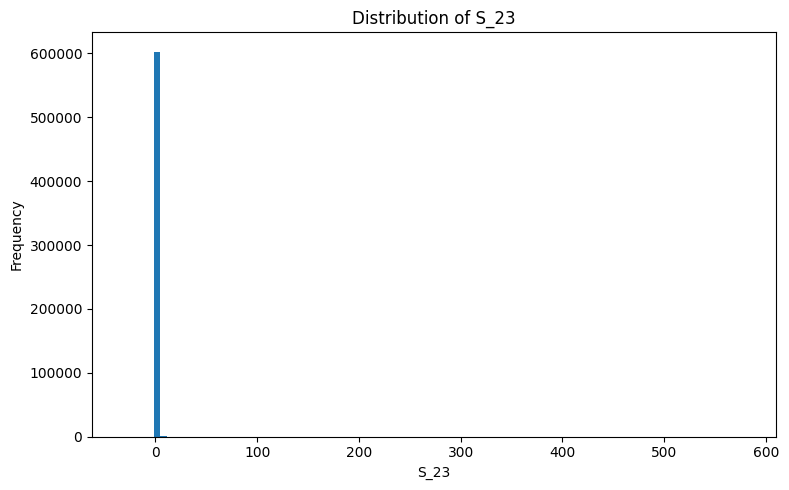

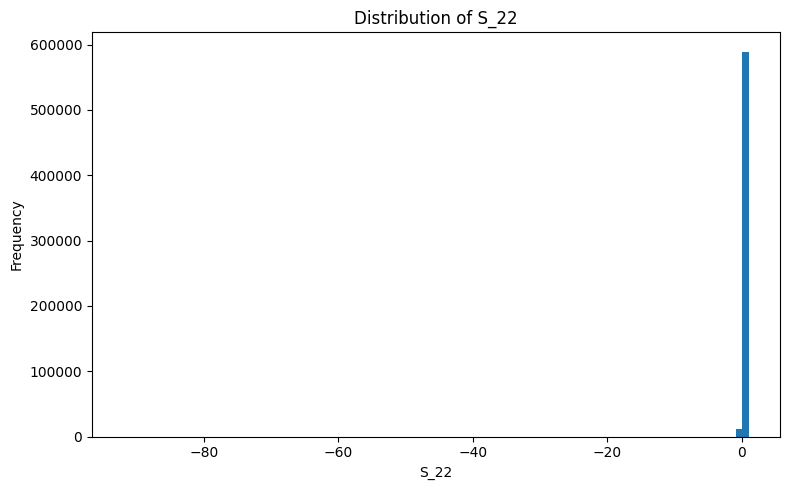

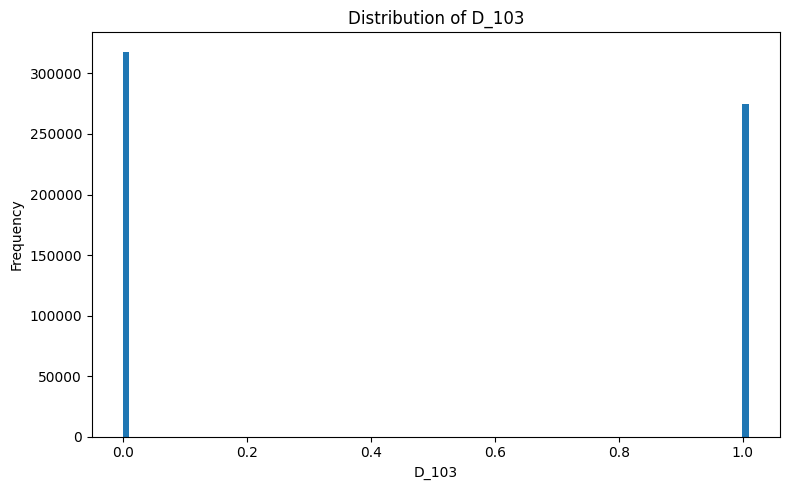

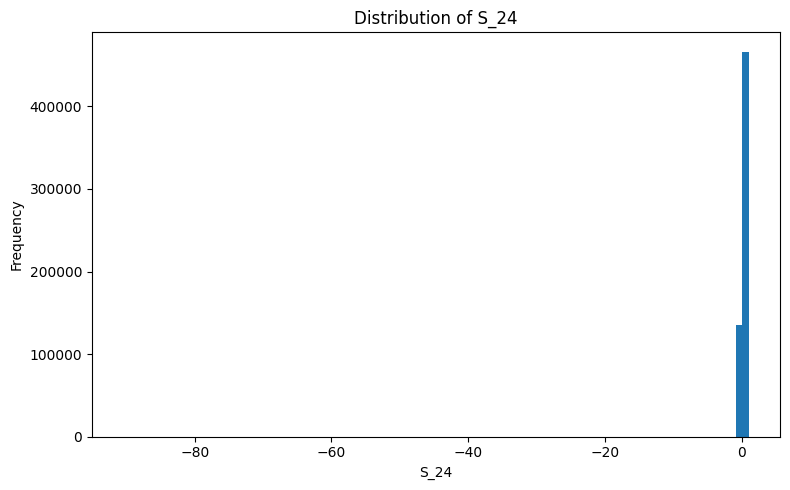

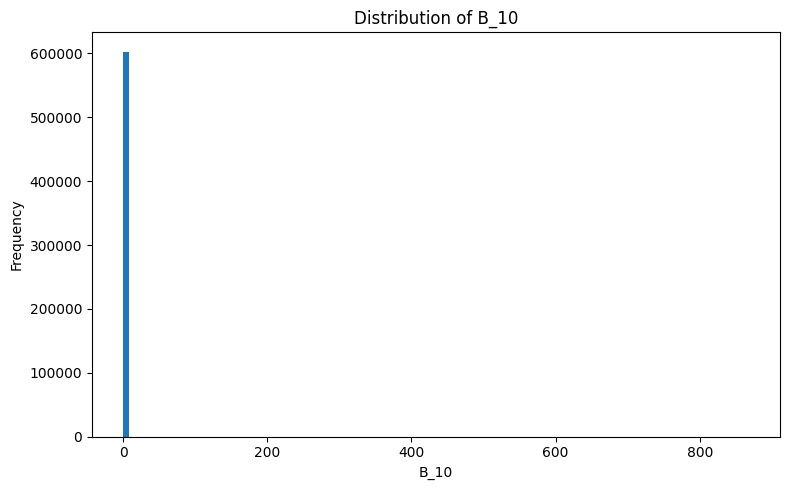

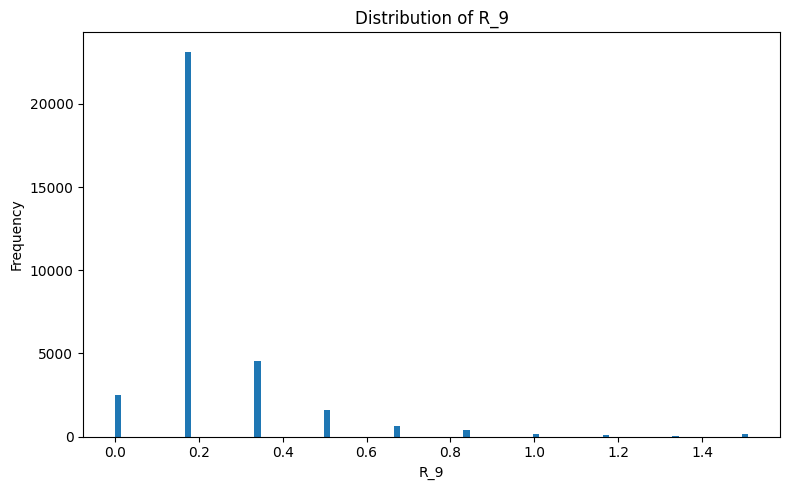

In [19]:
import matplotlib.pyplot as plt

representative_features = [
    "S_23",
    "S_22",
    "D_103",
    "S_24",
    "B_10",
    "R_9"
]

for feature in representative_features:

    x = dev_df[feature].dropna()

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(x, bins=100)

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

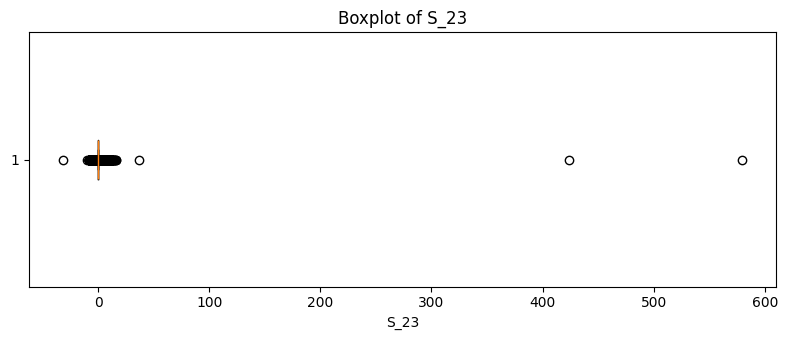

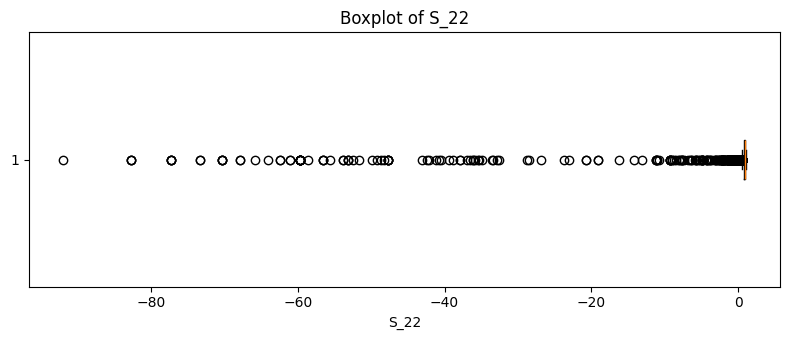

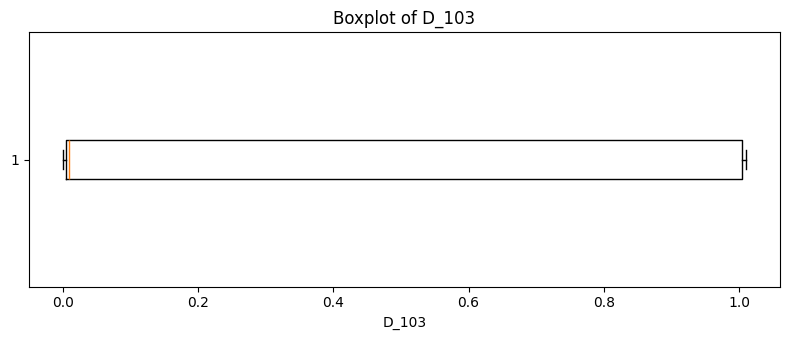

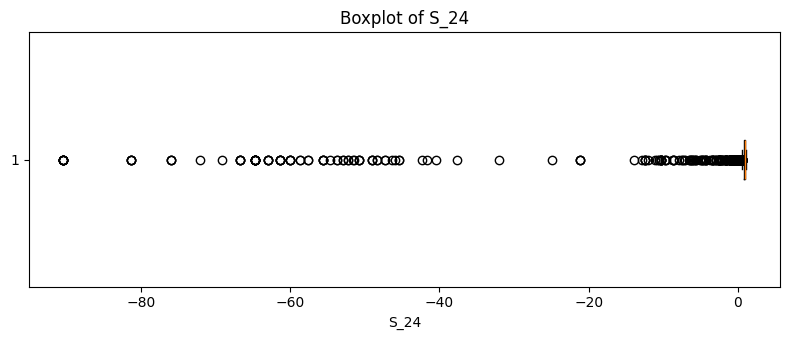

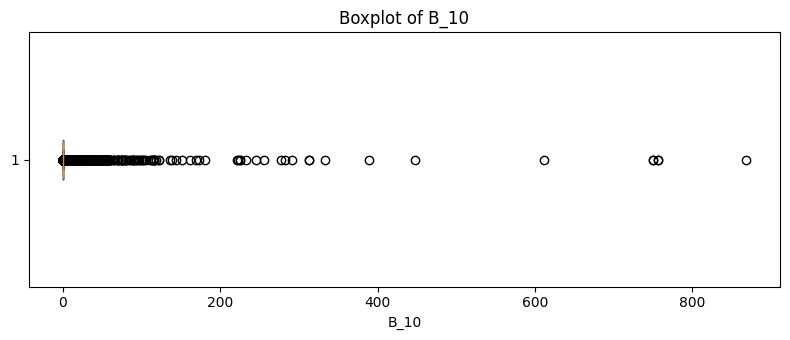

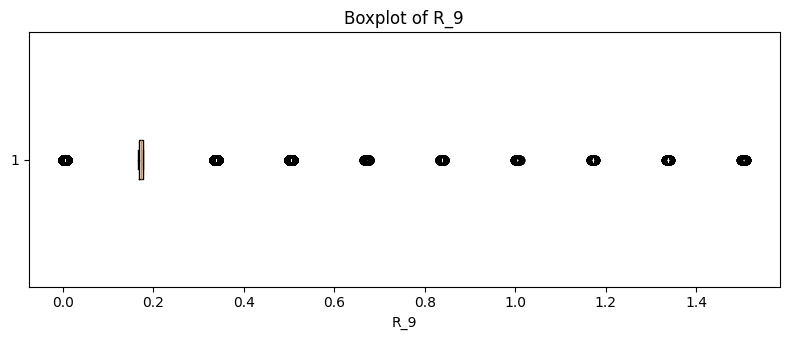

In [20]:
import matplotlib.pyplot as plt

representative_features = [
    "S_23",   # extreme right skew
    "S_22",   # extreme left skew
    "D_103",  # relatively symmetric
    "S_24",   # left skew + high outliers
    "B_10",   # extreme right tail
    "R_9"     # high missingness + high outlier percentage
]

for feature in representative_features:

    x = dev_df[feature].dropna()

    plt.figure(figsize=(8, 3.5))

    plt.boxplot(
        x,
        vert=False
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [21]:
# EDA 3.2 — DISCRETE NUMERICAL VARIABLES
# Step 1: Frequency Analysis


for feature in discrete_numeric_features:

    print("\n" + "=" * 70)
    print(f"FEATURE: {feature}")

    freq = (
        dev_df[feature]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    freq["percentage"] = (
        freq["count"] / len(dev_df) * 100
    )

    display(freq)


FEATURE: B_30


,count,percentage
B_30,,
0.0,515020,85.329808
1.0,82340,13.642298
2.0,6019,0.997243
NaN,185,0.030651



FEATURE: B_31


,count,percentage
B_31,,
1,601721,99.694647
0,1843,0.305353



FEATURE: B_38


...

,count,percentage
D_66,,
NaN,536330,88.860502
1.0,66541,11.024680
0.0,693,0.114818



FEATURE: D_68


,count,percentage
D_68,,
6.0,305529,50.620812
5.0,131208,21.738871
3.0,52441,8.688557
4.0,51328,8.504152
2.0,23607,3.911267
NaN,23382,3.873989
1.0,14299,2.369094
0.0,1770,0.293258



FEATURE: D_87


,count,percentage
D_87,,
NaN,603085,99.920638
1.0,479,0.079362


In [22]:
discrete_summary = pd.DataFrame(index=discrete_numeric_features)

discrete_summary["missing_pct"] = (
    dev_df[discrete_numeric_features]
    .isna()
    .mean() * 100
)

discrete_summary["unique_observed"] = (
    dev_df[discrete_numeric_features]
    .nunique(dropna=True)
)

discrete_summary["dominant_value"] = (
    dev_df[discrete_numeric_features]
    .mode(dropna=True)
    .iloc[0]
)

discrete_summary["dominant_value_pct"] = [
    dev_df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100
    for col in discrete_numeric_features
]

display(
    discrete_summary.sort_values(
        "dominant_value_pct",
        ascending=False
    )
)

,missing_pct,unique_observed,dominant_value,dominant_value_pct
D_87,99.920638,1,1.0,100.000000
D_116,3.119967,2,0.0,99.877038
B_31,0.000000,2,1.0,99.694647
D_66,88.860502,2,1.0,98.969271
D_120,3.119967,2,0.0,88.485514
B_30,0.030651,3,0.0,85.355970
D_126,2.064901,3,1.0,78.893116
D_114,3.119967,2,1.0,61.895942
D_68,3.873989,7,6.0,52.660889
B_38,0.030651,7,2.0,35.074638


In [23]:
# EDA 3.3 — Categorical / String Variables

categorical_features = dev_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical/String features:")
print(categorical_features)
print("\nNumber of categorical features:", len(categorical_features))

Categorical/String features:
['customer_ID', 'S_2', 'D_63', 'D_64']

Number of categorical features: 4


In [24]:
# Frequency Analysis of Categorical Variables

for feature in categorical_features:

    print("\n" + "=" * 70)
    print(f"FEATURE: {feature}")

    freq = (
        dev_df[feature]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    freq["percentage"] = (
        freq["count"] / len(dev_df) * 100
    )

    display(freq)


FEATURE: customer_ID


,count,percentage
customer_ID,,
ffedc7b44c349d5643f2df8868cf3078e15c02bcd69abf5113e3054171aacb8c,13,0.002154
ffed3d637bd646af55020b2c5c8c42b399d422f04f49edcf24e4d46bbab65486,13,0.002154
ffed1807bf7136617a0fcd8524a44bec177d4fb0644fc54a8aecf4ebab7821fc,13,0.002154
ffe91e4fea805cb0d8674ed37446fecdf1e57cf8d6d4c5bce541b88b3c673c3a,13,0.002154
ffe77187e738b50bfb8c86d25f9db82f7b3597e85f1fd5a1ebd155545b6312a6,13,0.002154
...,...,...
dd80eb55c0a910a8c0b3c5b909c8d5a441f7a97d3a2daca32898fe7da1c1ce33,1,0.000166
bd5370d436cd47dd5c99af6fff250caa426c5473d3beb91dbbd212f8609a6bb1,1,0.000166
e1831db897a14a77b12c22e3ac135b6a62e8ebb700bbc1ce8edbc1a134815cb0,1,0.000166



FEATURE: S_2


,count,percentage
S_2,,
2018-02-17,2838,0.470207
2018-01-20,2679,0.443863
2018-02-03,2637,0.436905
2018-02-24,2567,0.425307
2018-03-17,2563,0.424644
...,...,...
2017-05-07,865,0.143315
2017-03-05,856,0.141824
2017-09-10,833,0.138014



FEATURE: D_63


,count,percentage
D_63,,
CO,448840,74.364939
CR,101411,16.802029
CL,48543,8.042726
XZ,2922,0.484124
XM,1114,0.184570
XL,734,0.121611



FEATURE: D_64


,count,percentage
D_64,,
O,319270,52.897456
U,166533,27.591606
R,90273,14.956657
None,23354,3.869349
-1,4134,0.684932


In [28]:
print(dev_df["D_64"].dtype)

print("\nMissing values:")
print(dev_df["D_64"].isna().sum())

print("\nUnique values:")
print(dev_df["D_64"].unique())

object

Missing values:
23354

Unique values:
[None 'R' 'O' 'U' '-1']


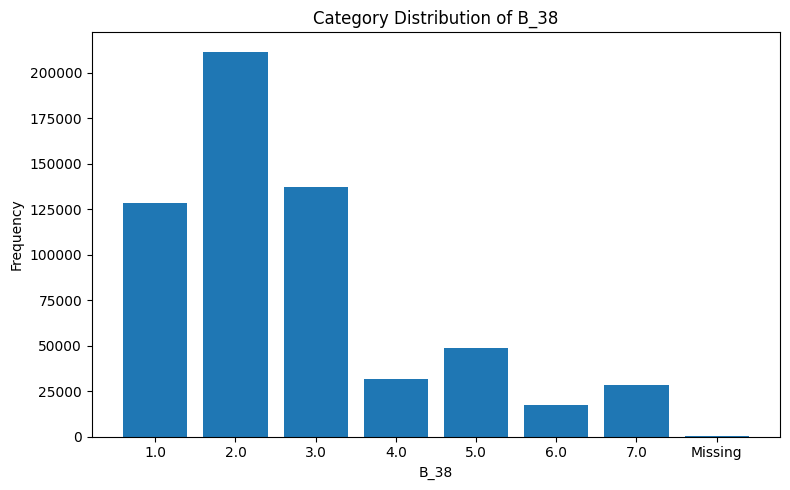

In [26]:

#Bar Plot

feature = "B_38"

freq = (
    dev_df[feature]
    .value_counts(dropna=False)
    .sort_index()
)

labels = [
    "Missing" if pd.isna(x) else str(x)
    for x in freq.index
]

plt.figure(figsize=(8, 5))

plt.bar(labels, freq.values)

plt.title(f"Category Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

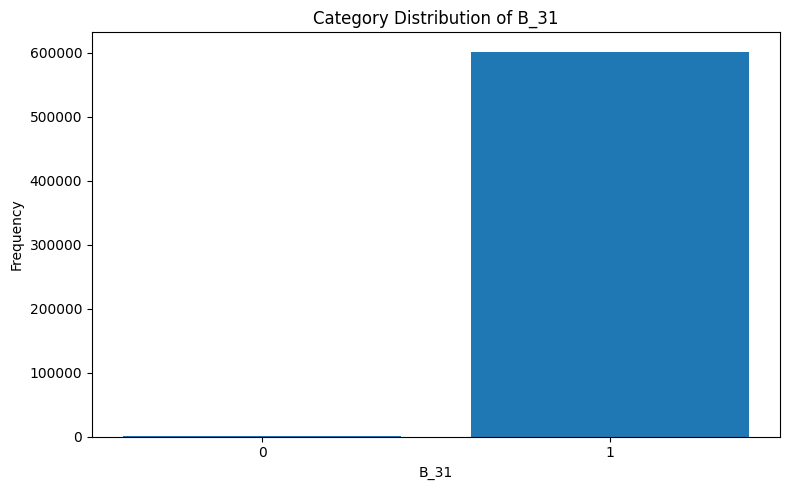

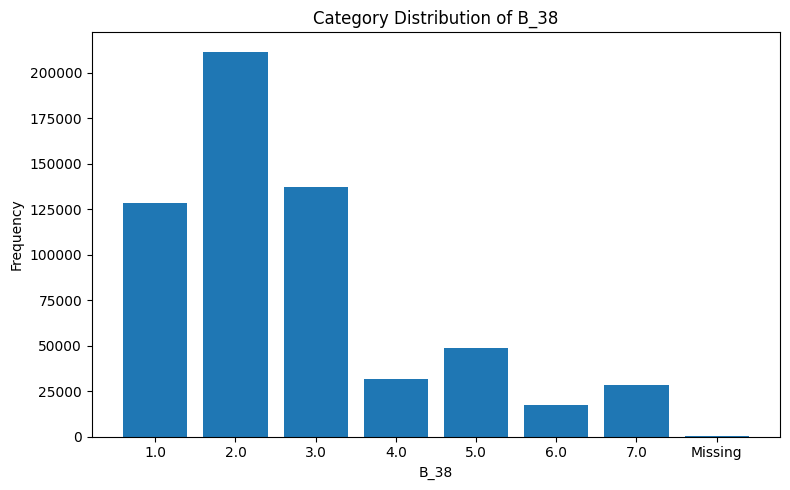

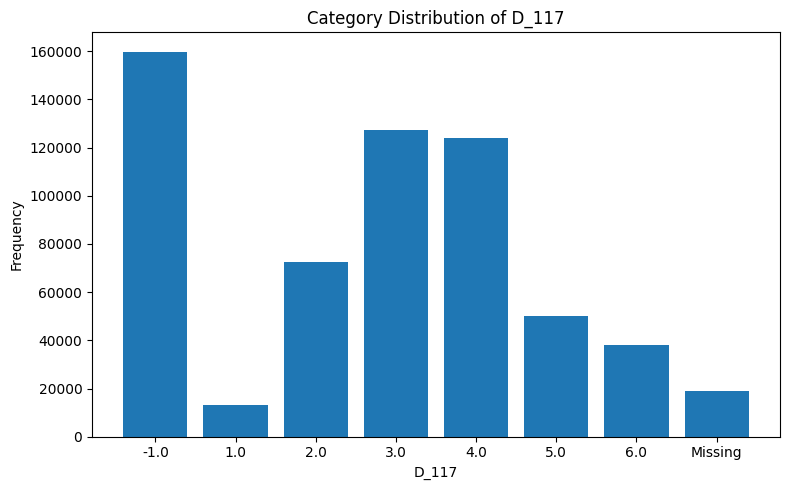

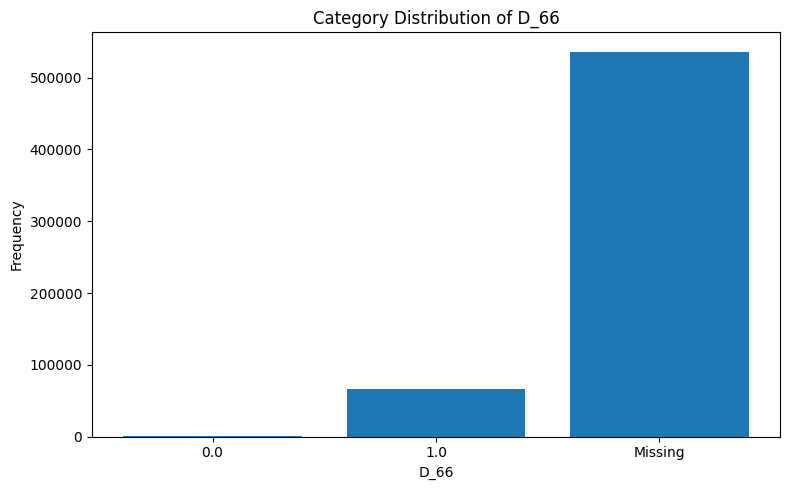

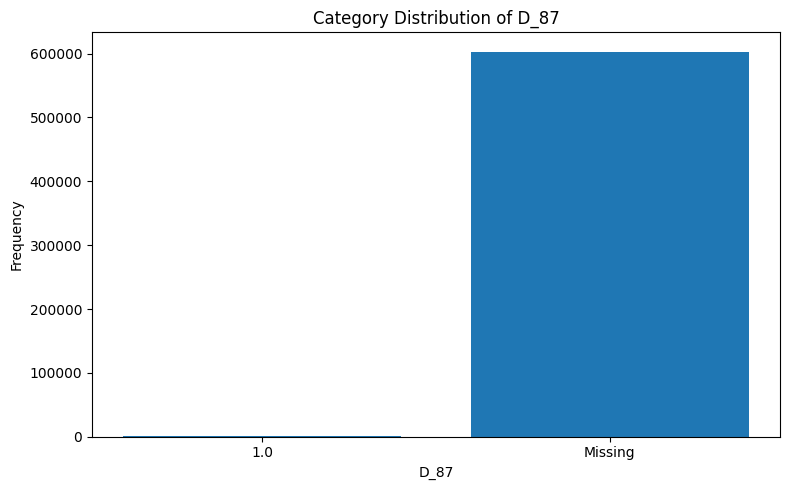

In [27]:
representative_discrete = [
    "B_31",
    "B_38",
    "D_117",
    "D_66",
    "D_87"
]

for feature in representative_discrete:

    freq = (
        dev_df[feature]
        .value_counts(dropna=False)
        .sort_index()
    )

    labels = [
        "Missing" if pd.isna(x) else str(x)
        for x in freq.index
    ]

    plt.figure(figsize=(8, 5))

    plt.bar(labels, freq.values)

    plt.title(f"Category Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
    

*EDA 4 — Feature vs Target Analysis*

In [29]:
customer_target = (
    dev_df[["customer_ID", "target"]]
    .drop_duplicates()
)

print("===== CUSTOMER-LEVEL TARGET =====")

print("Unique customers:", len(customer_target))

print("\nTarget counts:")
print(customer_target["target"].value_counts())

print("\nTarget proportions:")
print(
    customer_target["target"]
    .value_counts(normalize=True)
    .sort_index()
)

default_rate = customer_target["target"].mean()

print(
    f"\nOverall customer-level default rate: "
    f"{default_rate:.4%}"
)

===== CUSTOMER-LEVEL TARGET =====
Unique customers: 50000

Target counts:
target
0    37288
1    12712
Name: count, dtype: int64

Target proportions:
target
0    0.74576
1    0.25424
Name: proportion, dtype: float64

Overall customer-level default rate: 25.4240%


In [30]:
# Make sure S_2 is datetime
dev_df["S_2"] = pd.to_datetime(dev_df["S_2"])

# Sort chronologically within customer
dev_sorted = dev_df.sort_values(
    ["customer_ID", "S_2"]
)

# Latest observation for each customer
latest_df = (
    dev_sorted
    .groupby("customer_ID", sort=False)
    .tail(1)
    .copy()
)

print("Latest customer snapshot shape:", latest_df.shape)
print(
    "Unique customers:",
    latest_df["customer_ID"].nunique()
)

print(
    "Latest statement date range:",
    latest_df["S_2"].min(),
    "to",
    latest_df["S_2"].max()
)

Latest customer snapshot shape: (50000, 191)
Unique customers: 50000
Latest statement date range: 2018-03-01 00:00:00 to 2018-03-31 00:00:00


In [31]:
# EDA 4.3 — CONTINUOUS FEATURES VS TARGET
# Quantile-based default rates
# ============================================================

continuous_for_target = continuous_numeric_features.copy()

# Remove variables with extremely high missingness for this
# first-pass analysis.
continuous_for_target = [
    col for col in continuous_for_target
    if latest_df[col].notna().mean() >= 0.50
]

print(
    "Continuous features available for target analysis:",
    len(continuous_for_target)
)

Continuous features available for target analysis: 148


In [33]:
def quantile_default_analysis(
    df,
    feature,
    target="target",
    n_bins=5
):
    """
    Divide a continuous feature into quantile groups
    and calculate customer-level default rates.
    """

    temp = df[[feature, target]].dropna().copy()

    # Avoid qcut failure for variables with many tied values
    temp["quantile"] = pd.qcut(
        temp[feature],
        q=n_bins,
        duplicates="drop"
    )

    result = (
        temp.groupby("quantile", observed=True)
        .agg(
            customers=(target, "size"),
            defaults=(target, "sum"),
            default_rate=(target, "mean")
        )
        .reset_index()
    )

    result["default_rate_pct"] = (
        result["default_rate"] * 100
    )

    result["feature"] = feature

    return result

In [34]:
target_analysis_features = [
    "B_1",
    "B_10",
    "B_12",
    "S_5",
    "S_6",
    "S_12",
    "S_23",
    "R_14",
    "D_69",
    "B_26"
]

target_analysis_results = []

for feature in target_analysis_features:

    if feature not in latest_df.columns:
        continue

    if latest_df[feature].notna().sum() < 100:
        continue

    result = quantile_default_analysis(
        latest_df,
        feature
    )

    target_analysis_results.append(result)

target_analysis_results = pd.concat(
    target_analysis_results,
    ignore_index=True
)

display(target_analysis_results)

,quantile,customers,defaults,default_rate,default_rate_pct,feature
0,"(-0.362, 0.00738]",10000,492,0.049200,4.920000,B_1
1,"(0.00738, 0.0205]",10000,504,0.050400,5.040000,B_1
2,"(0.0205, 0.0575]",10000,1119,0.111900,11.190000,B_1
3,"(0.0575, 0.217]",10000,4535,0.453500,45.350000,B_1
4,"(0.217, 1.324]",10000,6062,0.606200,60.620000,B_1
5,"(-0.00394, 0.0211]",10000,5723,0.572300,57.230000,B_10
6,"(0.0211, 0.0526]",10000,4460,0.446000,44.600000,B_10
7,"(0.0526, 0.211]",10000,2002,0.200200,20.020000,B_10
8,"(0.211, 0.297]",10000,337,0.033700,3.370000,B_10
9,"(0.297, 868.013]",10000,190,0.019000,1.900000,B_10


In [36]:
# ============================================================
# EDA 4.4 — AUTOMATED CONTINUOUS FEATURE SCREENING
# ============================================================

import numpy as np
import pandas as pd

screening_results = []

for feature in continuous_numeric_features:

    temp = latest_df[[feature, "target"]].dropna().copy()

    # Skip features with too few observations
    if len(temp) < 500:
        continue

    # Create 5 approximately equal-sized quantile groups
    temp["bin"] = pd.qcut(
        temp[feature],
        q=5,
        duplicates="drop"
    )

    grouped = (
        temp.groupby("bin", observed=True)["target"]
        .agg(["mean", "count"])
    )

    # Need at least 5 bins
    if len(grouped) < 5:
        continue

    q1_rate = grouped["mean"].iloc[0]
    q5_rate = grouped["mean"].iloc[-1]

    screening_results.append({
        "feature": feature,

        "missing_pct_latest": (
            latest_df[feature].isna().mean() * 100
        ),

        "customers_used": len(temp),

        "q1_default_rate": q1_rate * 100,

        "q5_default_rate": q5_rate * 100,

        "q5_minus_q1_pp": (
            (q5_rate - q1_rate) * 100
        ),

        "min_bin_default_rate": (
            grouped["mean"].min() * 100
        ),

        "max_bin_default_rate": (
            grouped["mean"].max() * 100
        ),

        "risk_range_pp": (
            (grouped["mean"].max()
             - grouped["mean"].min()) * 100
        ),

        "skewness": continuous_profile.loc[
            feature, "skewness"
        ]
    })


# Convert results to DataFrame
continuous_target_screening = pd.DataFrame(
    screening_results
)

# Rank by total difference between highest- and lowest-risk bins
continuous_target_screening = (
    continuous_target_screening
    .sort_values(
        "risk_range_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Number of continuous features screened:",
    len(continuous_target_screening)
)

display(
    continuous_target_screening.head(30)
)

Number of continuous features screened: 169


,feature,missing_pct_latest,customers_used,q1_default_rate,q5_default_rate,q5_minus_q1_pp,min_bin_default_rate,max_bin_default_rate,risk_range_pp,skewness
0,P_2,0.608,49696,75.975855,0.382332,-75.593523,0.382332,75.975855,75.593523,-0.639121
1,D_48,12.658,43671,1.431025,71.948706,70.517682,1.431025,71.948706,70.517682,0.969203
2,D_42,87.284,6358,4.952830,73.191824,68.238994,4.952830,73.191824,68.238994,4.437389
3,B_9,0.000,50000,9.300000,73.090000,63.790000,5.790000,73.090000,67.300000,4.396297
4,D_61,10.504,44748,1.810056,67.664804,65.854749,1.810056,67.664804,65.854749,11.954170
5,D_44,4.798,47601,6.932045,70.147059,63.215014,6.292017,70.147059,63.855042,3.034033
6,D_55,6.642,46679,2.774207,63.624679,60.850471,2.774207,63.624679,60.850471,0.907201
7,B_2,0.002,49999,66.310000,5.500000,-60.810000,5.500000,66.310000,60.810000,-0.559203
8,D_75,0.000,50000,2.370000,62.990000,60.620000,2.370000,62.990000,60.620000,2.310281
9,B_3,0.002,49999,5.510000,65.470000,59.960000,5.510000,65.470000,59.960000,2.235789


In [37]:
print("===== STRONGEST POSITIVE Q5-Q1 RELATIONSHIPS =====")

display(
    continuous_target_screening
    .sort_values(
        "q5_minus_q1_pp",
        ascending=False
    )
    .head(20)
)

===== STRONGEST POSITIVE Q5-Q1 RELATIONSHIPS =====


,feature,missing_pct_latest,customers_used,q1_default_rate,q5_default_rate,q5_minus_q1_pp,min_bin_default_rate,max_bin_default_rate,risk_range_pp,skewness
1,D_48,12.658,43671,1.431025,71.948706,70.517682,1.431025,71.948706,70.517682,0.969203
2,D_42,87.284,6358,4.952830,73.191824,68.238994,4.952830,73.191824,68.238994,4.437389
4,D_61,10.504,44748,1.810056,67.664804,65.854749,1.810056,67.664804,65.854749,11.954170
3,B_9,0.000,50000,9.300000,73.090000,63.790000,5.790000,73.090000,67.300000,4.396297
5,D_44,4.798,47601,6.932045,70.147059,63.215014,6.292017,70.147059,63.855042,3.034033
6,D_55,6.642,46679,2.774207,63.624679,60.850471,2.774207,63.624679,60.850471,0.907201
8,D_75,0.000,50000,2.370000,62.990000,60.620000,2.370000,62.990000,60.620000,2.310281
9,B_3,0.002,49999,5.510000,65.470000,59.960000,5.510000,65.470000,59.960000,2.235789
10,B_7,0.000,50000,2.200000,61.520000,59.320000,2.200000,61.520000,59.320000,1.802696
11,B_23,0.000,50000,2.330000,61.580000,59.250000,2.330000,61.580000,59.250000,1.895612


In [38]:
print("===== STRONGEST NEGATIVE Q5-Q1 RELATIONSHIPS =====")

display(
    continuous_target_screening
    .sort_values(
        "q5_minus_q1_pp",
        ascending=True
    )
    .head(20)
)

===== STRONGEST NEGATIVE Q5-Q1 RELATIONSHIPS =====


,feature,missing_pct_latest,customers_used,q1_default_rate,q5_default_rate,q5_minus_q1_pp,min_bin_default_rate,max_bin_default_rate,risk_range_pp,skewness
0,P_2,0.608,49696,75.975855,0.382332,-75.593523,0.382332,75.975855,75.593523,-0.639121
7,B_2,0.002,49999,66.310000,5.500000,-60.810000,5.500000,66.310000,60.810000,-0.559203
12,D_62,12.626,43687,61.673152,2.780957,-58.892195,2.780957,61.673152,58.892195,2.596548
13,B_6,0.006,49997,61.070000,2.660000,-58.410000,2.660000,61.070000,58.410000,193.996582
15,B_18,0.000,50000,59.990000,1.910000,-58.080000,1.910000,59.990000,58.080000,-0.155195
21,B_10,0.000,50000,57.230000,1.900000,-55.330000,1.900000,57.230000,55.330000,177.849854
26,D_77,46.402,26799,50.951493,2.201493,-48.750000,2.201493,50.951493,48.750000,2.253208
30,B_33,0.002,49999,52.260000,6.310000,-45.950000,5.930000,52.260000,46.330000,-0.445597
35,D_52,0.246,49877,52.706496,8.239775,-44.466720,8.239775,52.706496,44.466720,2.878788
36,P_3,4.754,47623,56.104987,16.241470,-39.863517,13.513230,56.104987,42.591757,-1.184378


In [39]:
# ============================================================
# EDA 4.5 — DISCRETE NUMERICAL FEATURES VS TARGET
# ============================================================

discrete_target_results = []

for feature in discrete_numeric_features:

    temp = latest_df[[feature, "target"]].copy()

    # Represent missing explicitly
    temp[feature] = temp[feature].astype("object")
    temp[feature] = temp[feature].where(
        temp[feature].notna(),
        "Missing"
    )

    grouped = (
        temp.groupby(feature)["target"]
        .agg(
            customers="size",
            defaults="sum",
            default_rate="mean"
        )
        .reset_index()
    )

    grouped["default_rate_pct"] = (
        grouped["default_rate"] * 100
    )

    grouped["feature"] = feature

    discrete_target_results.append(grouped)

discrete_target_analysis = pd.concat(
    discrete_target_results,
    ignore_index=True
)

display(
    discrete_target_analysis[
        [
            "feature",
            discrete_target_analysis.columns[0],
            "customers",
            "defaults",
            "default_rate_pct"
        ]
    ]
)

,feature,B_30,customers,defaults,default_rate_pct
0,B_30,0.0,41824,7418,17.736228
1,B_30,1.0,7665,4965,64.774951
2,B_30,2.0,510,329,64.509804
3,B_30,Missing,1,0,0.000000
4,B_31,NaN,297,266,89.562290
5,B_31,NaN,49703,12446,25.040742
6,B_38,NaN,10490,932,8.884652
7,B_38,NaN,16582,844,5.089856
8,B_38,NaN,11382,3860,33.913196
9,B_38,NaN,2796,1995,71.351931


In [40]:
print("===== HIGHEST-RISK DISCRETE CATEGORIES =====")

display(
    discrete_target_analysis
    .sort_values(
        "default_rate_pct",
        ascending=False
    )
    .head(30)
)

===== HIGHEST-RISK DISCRETE CATEGORIES =====


,B_30,customers,defaults,default_rate,default_rate_pct,feature,B_31,B_38,D_114,D_116,D_117,D_120,D_126,D_66,D_68,D_87
42,NaN,68,62,0.911765,91.176471,D_87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,NaN,297,266,0.895623,89.562290,B_31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,2796,1995,0.713519,71.351931,B_38,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,1725,1130,0.655072,65.507246,B_38,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,7665,4965,0.647750,64.774951,B_30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,510,329,0.645098,64.509804,B_30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,137,85,0.620438,62.043796,D_116,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,4203,2442,0.581014,58.101356,B_38,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,2821,1509,0.534917,53.491670,B_38,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,NaN,9287,4446,0.478734,47.873371,D_120,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [41]:
categorical_target_features = [
    "D_63",
    "D_64"
]

In [42]:
# ============================================================
# CATEGORICAL FEATURES VS TARGET
# ============================================================

categorical_target_results = []

for feature in categorical_target_features:

    temp = latest_df[[feature, "target"]].copy()

    temp[feature] = temp[feature].astype("object")

    temp[feature] = temp[feature].where(
        temp[feature].notna(),
        "Missing"
    )

    grouped = (
        temp.groupby(feature)["target"]
        .agg(
            customers="size",
            defaults="sum",
            default_rate="mean"
        )
        .reset_index()
    )

    grouped["default_rate_pct"] = (
        grouped["default_rate"] * 100
    )

    grouped["feature"] = feature

    categorical_target_results.append(grouped)

categorical_target_analysis = pd.concat(
    categorical_target_results,
    ignore_index=True
)

display(categorical_target_analysis)

,D_63,customers,defaults,default_rate,default_rate_pct,feature,D_64
0,CL,3866,1172,0.303156,30.315572,D_63,NaN
1,CO,37498,9936,0.264974,26.497413,D_63,NaN
2,CR,8001,1421,0.177603,17.760280,D_63,NaN
3,XL,90,41,0.455556,45.555556,D_63,NaN
4,XM,170,46,0.270588,27.058824,D_63,NaN
5,XZ,375,96,0.256000,25.600000,D_63,NaN
6,NaN,1041,304,0.292027,29.202690,D_64,Missing
7,NaN,26767,4623,0.172713,17.271267,D_64,O
8,NaN,7756,2540,0.327488,32.748840,D_64,R
9,NaN,14436,5245,0.363328,36.332779,D_64,U


In [43]:
# ============================================================
# EDA 4.6 — MISSINGNESS VS TARGET
# ============================================================

missing_target_results = []

all_predictor_features = (
    continuous_numeric_features
    + discrete_numeric_features
    + categorical_target_features
)

for feature in all_predictor_features:

    if feature not in latest_df.columns:
        continue

    temp = latest_df[[feature, "target"]].copy()

    temp["missing_group"] = np.where(
        temp[feature].isna(),
        "Missing",
        "Observed"
    )

    grouped = (
        temp.groupby("missing_group")["target"]
        .agg(
            customers="size",
            defaults="sum",
            default_rate="mean"
        )
        .reset_index()
    )

    rates = dict(
        zip(
            grouped["missing_group"],
            grouped["default_rate"]
        )
    )

    missing_target_results.append({
        "feature": feature,
        "missing_customers": (
            grouped.loc[
                grouped["missing_group"] == "Missing",
                "customers"
            ].sum()
        ),
        "observed_customers": (
            grouped.loc[
                grouped["missing_group"] == "Observed",
                "customers"
            ].sum()
        ),
        "default_rate_missing": (
            rates.get("Missing", np.nan) * 100
        ),
        "default_rate_observed": (
            rates.get("Observed", np.nan) * 100
        ),
        "difference_pp": (
            (rates.get("Missing", np.nan)
             - rates.get("Observed", np.nan)) * 100
        )
    })

missing_target_analysis = pd.DataFrame(
    missing_target_results
)

In [44]:
# ============================================================
# Rank features by missingness-target association
# ============================================================

missing_target_analysis["abs_difference_pp"] = (
    missing_target_analysis["difference_pp"].abs()
)

missing_target_analysis = (
    missing_target_analysis
    .sort_values(
        "abs_difference_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

print("===== TOP FEATURES BY MISSINGNESS-TARGET ASSOCIATION =====")

display(
    missing_target_analysis.head(30)
)

===== TOP FEATURES BY MISSINGNESS-TARGET ASSOCIATION =====


,feature,missing_customers,observed_customers,default_rate_missing,default_rate_observed,difference_pp,abs_difference_pp
0,S_23,2,49998,100.000000,25.421017,74.578983,74.578983
1,D_87,49932,68,25.334455,91.176471,-65.842016,65.842016
2,D_88,49905,95,25.316101,82.105263,-56.789163,56.789163
3,S_25,159,49841,70.440252,25.280392,45.159860,45.159860
4,R_9,47097,2903,23.262628,60.489149,-37.226521,37.226521
5,R_26,44559,5441,21.450212,57.967285,-36.517073,36.517073
6,D_137,48271,1729,24.213296,59.224986,-35.011690,35.011690
7,D_138,48271,1729,24.213296,59.224986,-35.011690,35.011690
8,D_134,48271,1729,24.213296,59.224986,-35.011690,35.011690
9,D_135,48271,1729,24.213296,59.224986,-35.011690,35.011690


In [45]:
# ============================================================
# Reliable missingness associations
# ============================================================

reliable_missing_analysis = (
    missing_target_analysis[
        missing_target_analysis["missing_customers"] >= 100
    ]
    .sort_values(
        "abs_difference_pp",
        ascending=False
    )
)

print(
    "===== RELIABLE MISSINGNESS-TARGET ASSOCIATIONS ====="
)

display(
    reliable_missing_analysis.head(30)
)

===== RELIABLE MISSINGNESS-TARGET ASSOCIATIONS =====


,feature,missing_customers,observed_customers,default_rate_missing,default_rate_observed,difference_pp,abs_difference_pp
1,D_87,49932,68,25.334455,91.176471,-65.842016,65.842016
2,D_88,49905,95,25.316101,82.105263,-56.789163,56.789163
3,S_25,159,49841,70.440252,25.280392,45.159860,45.159860
4,R_9,47097,2903,23.262628,60.489149,-37.226521,37.226521
5,R_26,44559,5441,21.450212,57.967285,-36.517073,36.517073
6,D_137,48271,1729,24.213296,59.224986,-35.011690,35.011690
7,D_138,48271,1729,24.213296,59.224986,-35.011690,35.011690
8,D_134,48271,1729,24.213296,59.224986,-35.011690,35.011690
9,D_135,48271,1729,24.213296,59.224986,-35.011690,35.011690
10,D_136,48271,1729,24.213296,59.224986,-35.011690,35.011690


In [46]:
# ============================================================
# EDA 4.7.1 — STRONGEST CONTINUOUS FEATURES
# Default Rate Across Quantile Groups
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Select top 5 continuous features
top_continuous_features = (
    continuous_target_screening
    .sort_values("risk_range_pp", ascending=False)
    .head(5)["feature"]
    .tolist()
)

print("Top continuous features:")
print(top_continuous_features)

Top continuous features:
['P_2', 'D_48', 'D_42', 'B_9', 'D_61']


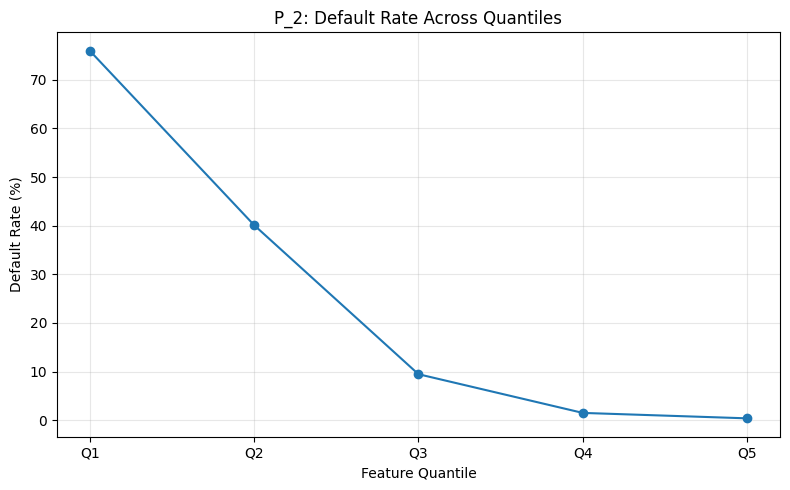

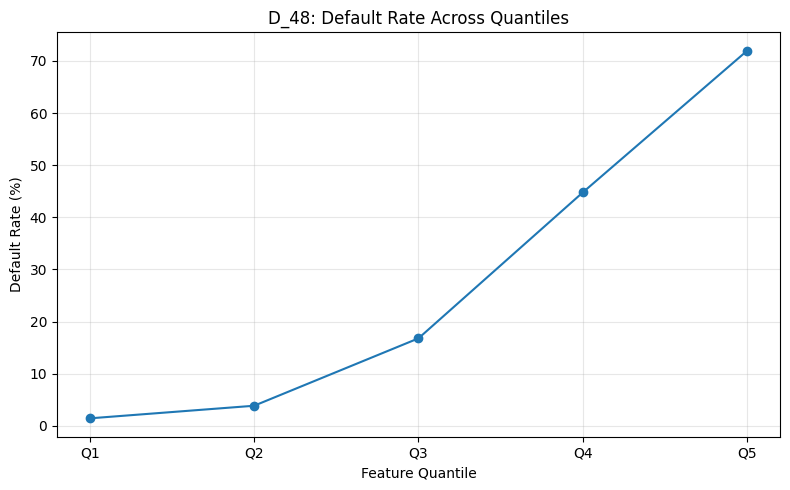

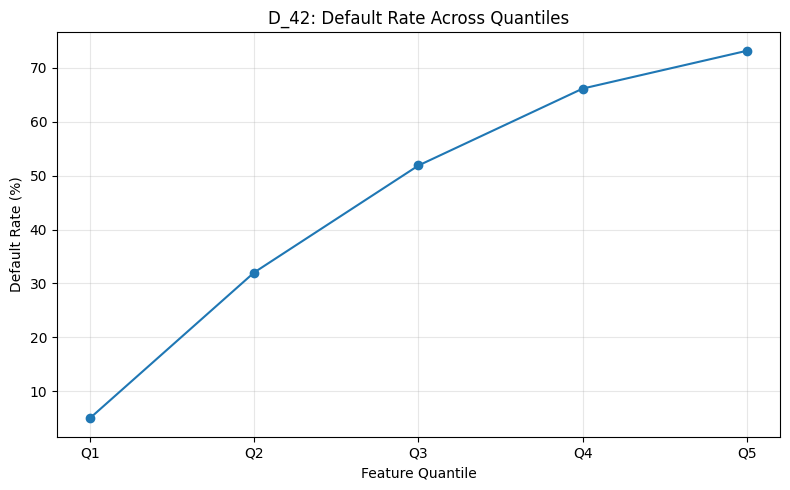

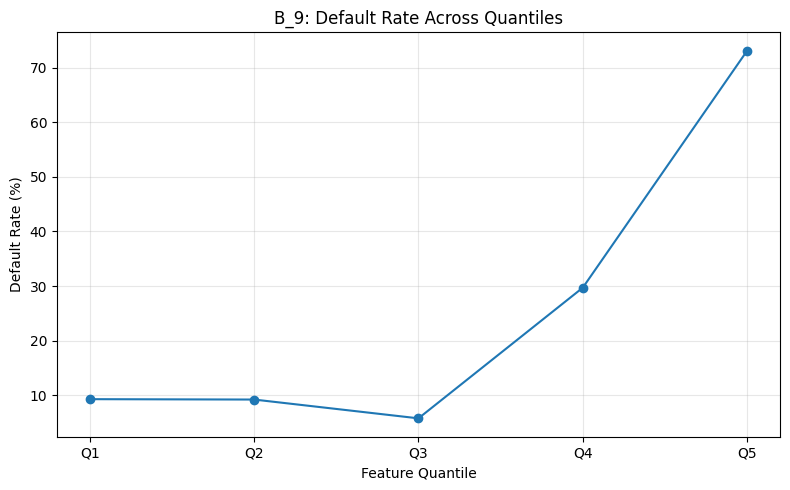

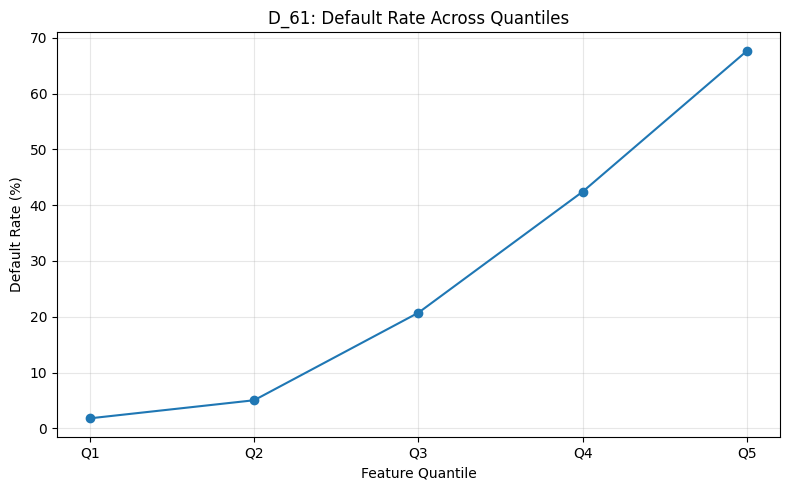

In [47]:
# ============================================================
# Plot default rate by quantile
# ============================================================

for feature in top_continuous_features:

    temp = latest_df[[feature, "target"]].dropna().copy()

    temp["quantile"] = pd.qcut(
        temp[feature],
        q=5,
        duplicates="drop"
    )

    grouped = (
        temp.groupby("quantile", observed=True)["target"]
        .mean()
        * 100
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        range(1, len(grouped) + 1),
        grouped.values,
        marker="o"
    )

    plt.xticks(
        range(1, len(grouped) + 1),
        [f"Q{i}" for i in range(1, len(grouped) + 1)]
    )

    plt.xlabel("Feature Quantile")
    plt.ylabel("Default Rate (%)")
    plt.title(
        f"{feature}: Default Rate Across Quantiles"
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [48]:
# ============================================================
# EDA 4.7.2 — DISCRETE/CATEGORICAL FEATURES
# ============================================================

all_category_target = pd.concat(
    [
        discrete_target_analysis,
        categorical_target_analysis
    ],
    ignore_index=True
)

# Calculate range of default rates within each feature
category_feature_summary = (
    all_category_target
    .groupby("feature")
    .agg(
        min_default_rate=("default_rate_pct", "min"),
        max_default_rate=("default_rate_pct", "max"),
        categories=("default_rate_pct", "size")
    )
)

category_feature_summary["risk_range_pp"] = (
    category_feature_summary["max_default_rate"]
    - category_feature_summary["min_default_rate"]
)

category_feature_summary = (
    category_feature_summary
    .sort_values("risk_range_pp", ascending=False)
)

display(category_feature_summary)

,min_default_rate,max_default_rate,categories,risk_range_pp
feature,,,,
B_38,0.000000,71.351931,8,71.351931
D_87,25.334455,91.176471,2,65.842016
B_30,0.000000,64.774951,4,64.774951
B_31,25.040742,89.562290,2,64.521548
D_116,25.247213,62.043796,3,36.796582
D_117,13.974970,46.959775,8,32.984805
D_63,17.760280,45.555556,6,27.795276
D_120,20.132672,47.873371,3,27.740700
D_68,18.134226,44.077135,7,25.942909


In [49]:
top_category_features = (
    category_feature_summary
    .head(5)
    .index
    .tolist()
)

print("Top discrete/categorical features:")
print(top_category_features)

Top discrete/categorical features:
['B_38', 'D_87', 'B_30', 'B_31', 'D_116']


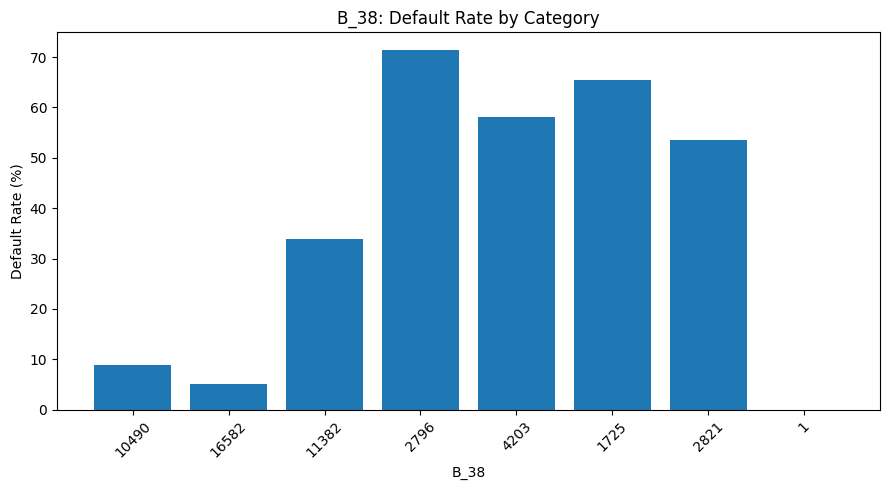

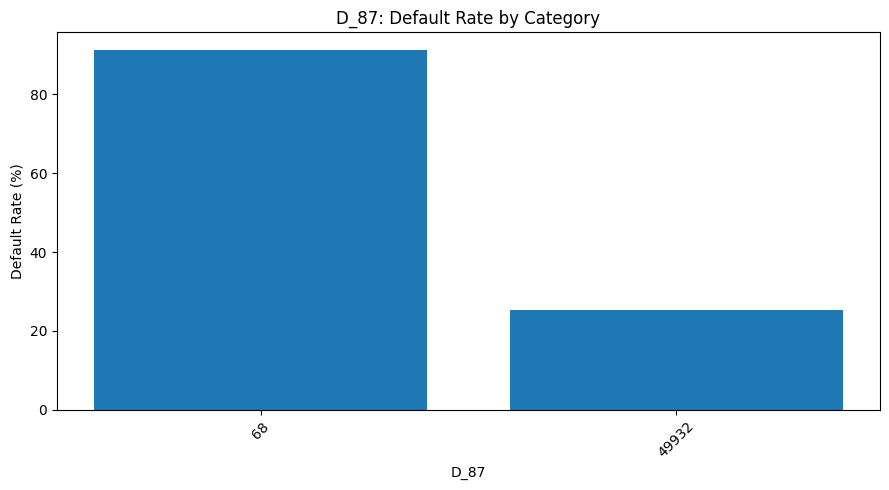

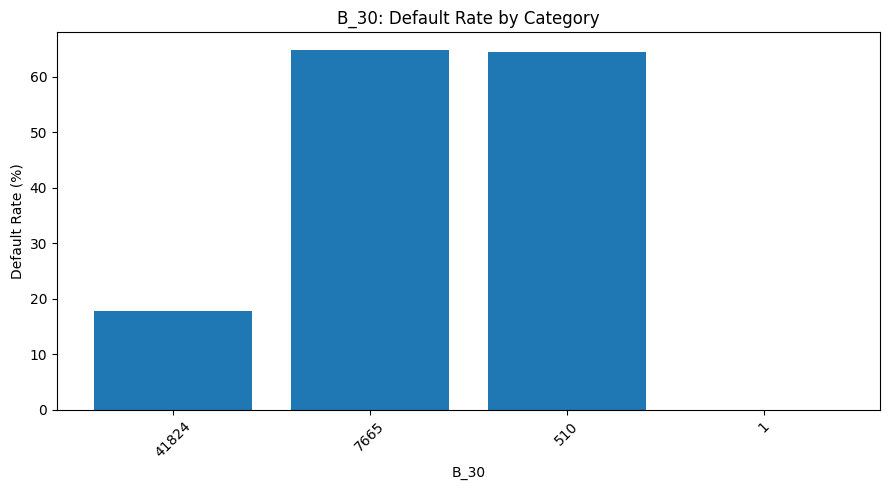

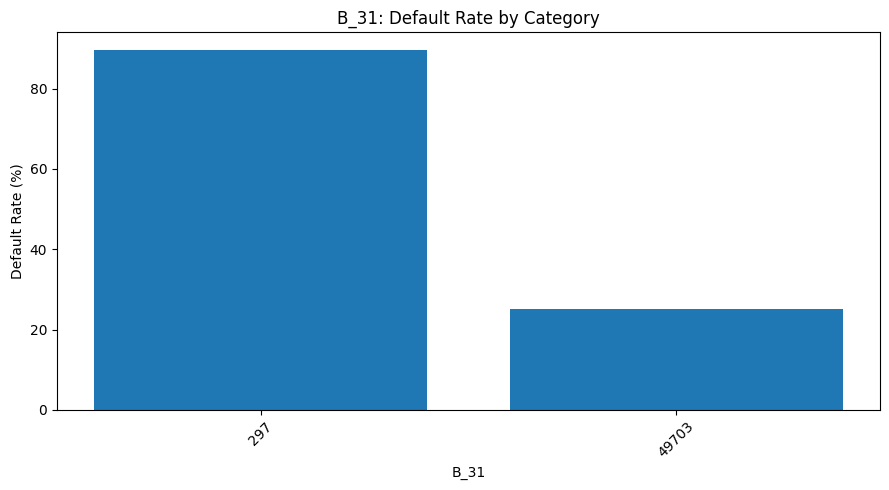

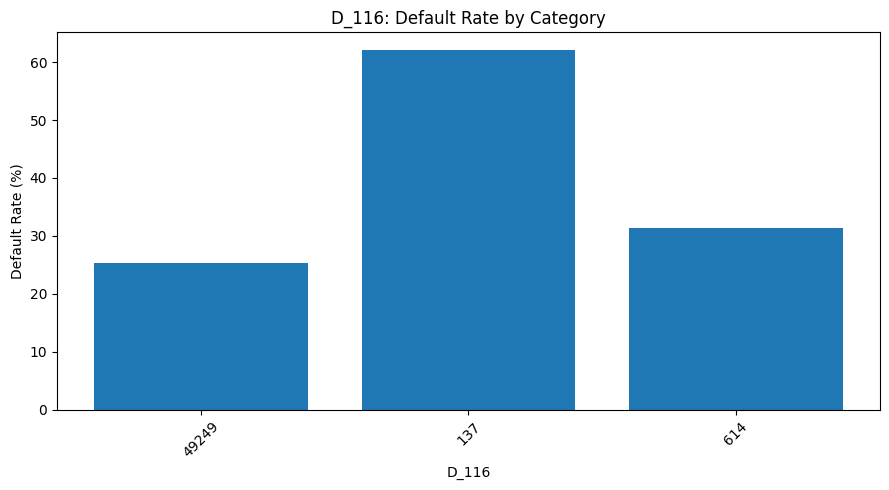

In [50]:
# ============================================================
# Plot category-wise default rates
# ============================================================

for feature in top_category_features:

    temp = all_category_target[
        all_category_target["feature"] == feature
    ].copy()

    plt.figure(figsize=(9, 5))

    plt.bar(
        temp.iloc[:, 1].astype(str),
        temp["default_rate_pct"]
    )

    plt.xlabel(feature)
    plt.ylabel("Default Rate (%)")
    plt.title(
        f"{feature}: Default Rate by Category"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [51]:
# ============================================================
# EDA 4.7.3 — MISSINGNESS VS DEFAULT
# ============================================================

top_missing_features = (
    reliable_missing_analysis
    .head(10)["feature"]
    .tolist()
)

print("Top missingness-related features:")
print(top_missing_features)

Top missingness-related features:
['D_87', 'D_88', 'S_25', 'R_9', 'R_26', 'D_137', 'D_138', 'D_134', 'D_135', 'D_136']


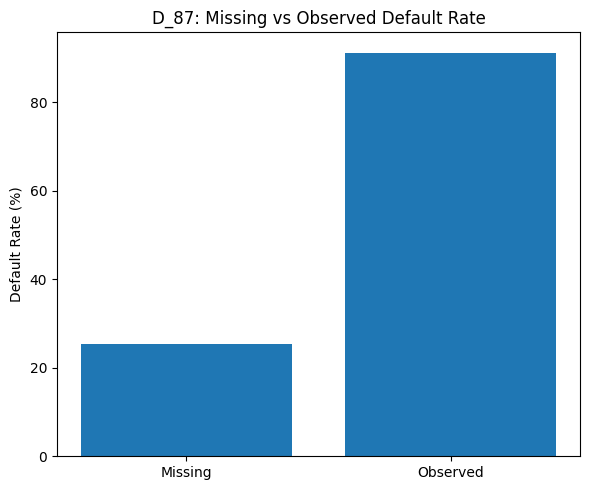

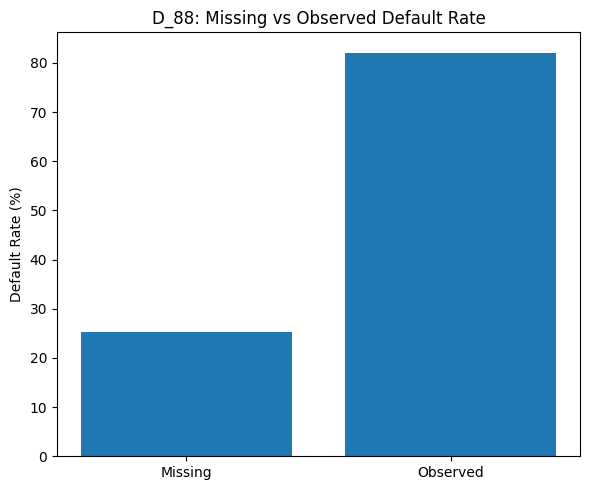

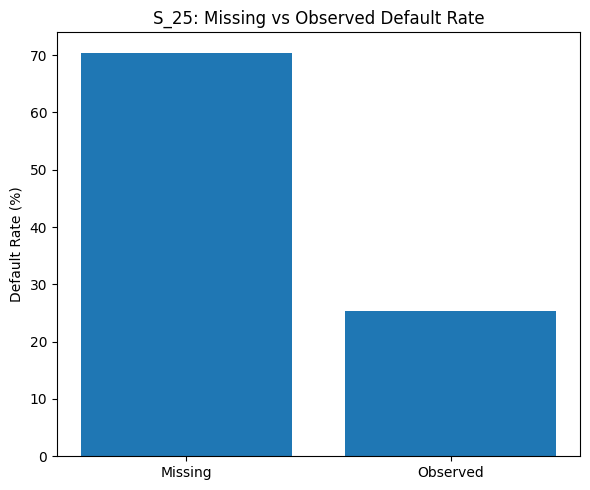

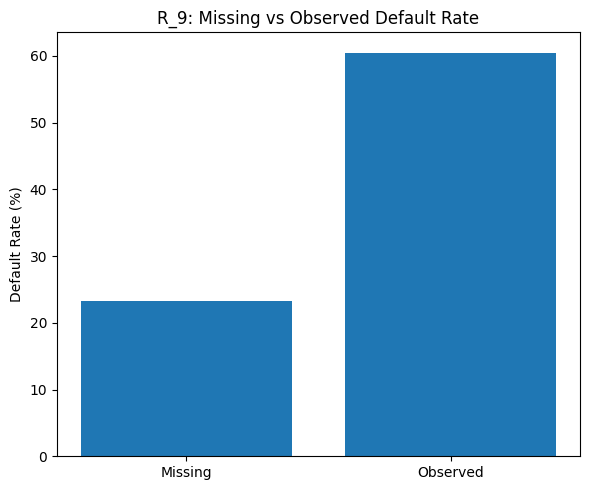

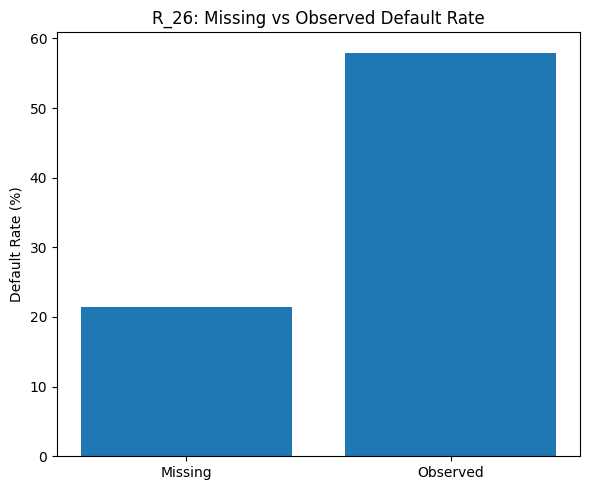

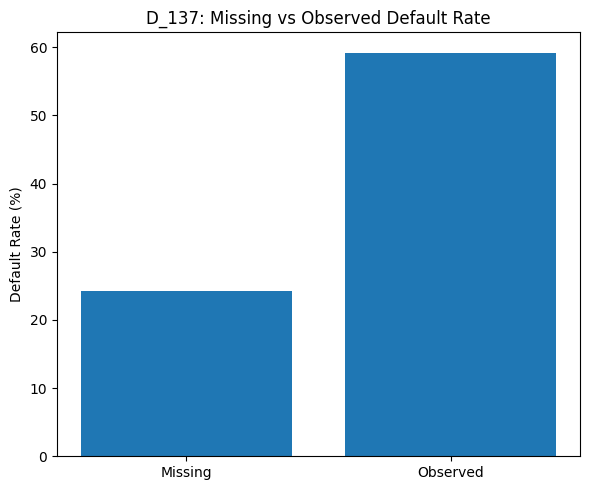

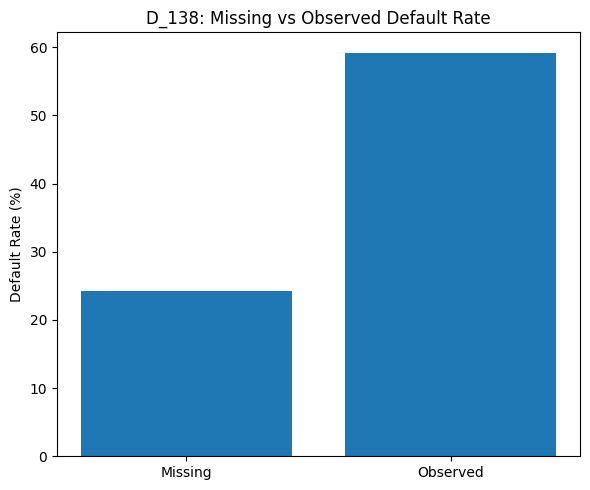

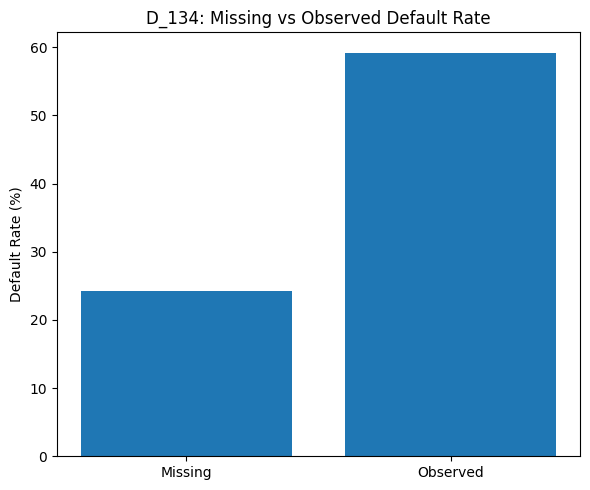

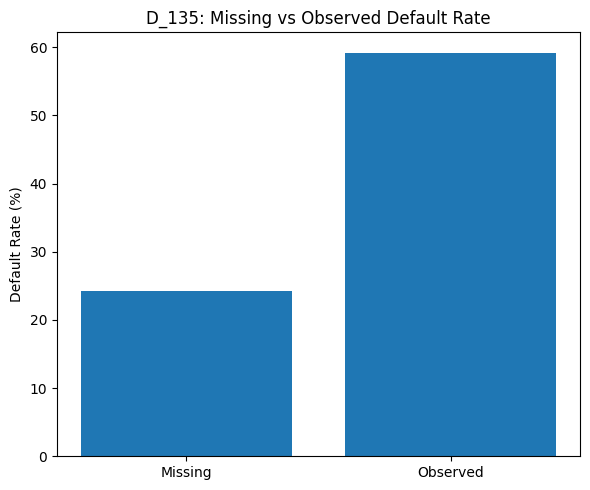

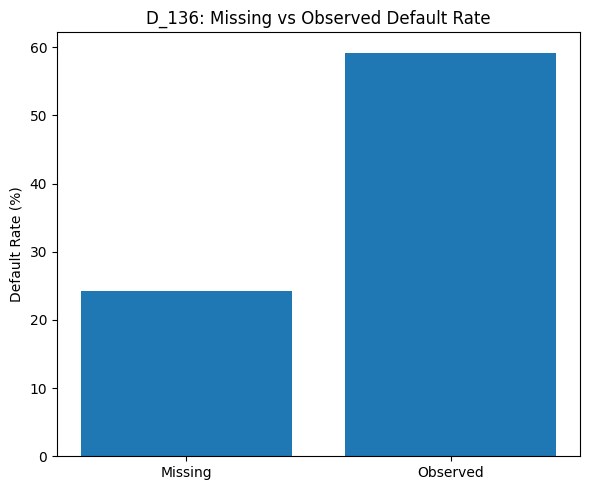

In [52]:
# ============================================================
# Missing vs Observed Default Rates
# ============================================================

for feature in top_missing_features:

    row = missing_target_analysis[
        missing_target_analysis["feature"] == feature
    ].iloc[0]

    groups = ["Missing", "Observed"]

    rates = [
        row["default_rate_missing"],
        row["default_rate_observed"]
    ]

    plt.figure(figsize=(6, 5))

    plt.bar(
        groups,
        rates
    )

    plt.ylabel("Default Rate (%)")
    plt.title(
        f"{feature}: Missing vs Observed Default Rate"
    )

    plt.tight_layout()
    plt.show()

In [53]:
# ============================================================
# FINAL EDA 4 SUMMARY
# ============================================================

top_continuous_summary = (
    continuous_target_screening
    .sort_values("risk_range_pp", ascending=False)
    .head(10)
    [
        [
            "feature",
            "q1_default_rate",
            "q5_default_rate",
            "q5_minus_q1_pp",
            "risk_range_pp"
        ]
    ]
)

print("===== TOP CONTINUOUS FEATURES =====")
display(top_continuous_summary)


print("===== TOP DISCRETE/CATEGORICAL FEATURES =====")

display(
    category_feature_summary
    .head(10)
)


print("===== TOP MISSINGNESS FEATURES =====")

display(
    reliable_missing_analysis
    .head(15)
)

===== TOP CONTINUOUS FEATURES =====


,feature,q1_default_rate,q5_default_rate,q5_minus_q1_pp,risk_range_pp
0,P_2,75.975855,0.382332,-75.593523,75.593523
1,D_48,1.431025,71.948706,70.517682,70.517682
2,D_42,4.952830,73.191824,68.238994,68.238994
3,B_9,9.300000,73.090000,63.790000,67.300000
4,D_61,1.810056,67.664804,65.854749,65.854749
5,D_44,6.932045,70.147059,63.215014,63.855042
6,D_55,2.774207,63.624679,60.850471,60.850471
7,B_2,66.310000,5.500000,-60.810000,60.810000
8,D_75,2.370000,62.990000,60.620000,60.620000
9,B_3,5.510000,65.470000,59.960000,59.960000


===== TOP DISCRETE/CATEGORICAL FEATURES =====


,min_default_rate,max_default_rate,categories,risk_range_pp
feature,,,,
B_38,0.000000,71.351931,8,71.351931
D_87,25.334455,91.176471,2,65.842016
B_30,0.000000,64.774951,4,64.774951
B_31,25.040742,89.562290,2,64.521548
D_116,25.247213,62.043796,3,36.796582
D_117,13.974970,46.959775,8,32.984805
D_63,17.760280,45.555556,6,27.795276
D_120,20.132672,47.873371,3,27.740700
D_68,18.134226,44.077135,7,25.942909


===== TOP MISSINGNESS FEATURES =====


,feature,missing_customers,observed_customers,default_rate_missing,default_rate_observed,difference_pp,abs_difference_pp
1,D_87,49932,68,25.334455,91.176471,-65.842016,65.842016
2,D_88,49905,95,25.316101,82.105263,-56.789163,56.789163
3,S_25,159,49841,70.440252,25.280392,45.159860,45.159860
4,R_9,47097,2903,23.262628,60.489149,-37.226521,37.226521
5,R_26,44559,5441,21.450212,57.967285,-36.517073,36.517073
6,D_137,48271,1729,24.213296,59.224986,-35.011690,35.011690
7,D_138,48271,1729,24.213296,59.224986,-35.011690,35.011690
8,D_134,48271,1729,24.213296,59.224986,-35.011690,35.011690
9,D_135,48271,1729,24.213296,59.224986,-35.011690,35.011690
10,D_136,48271,1729,24.213296,59.224986,-35.011690,35.011690


*EDA 5 — Temporal & Customer-History Analysis*

In [54]:
# ============================================================
# EDA 5.1 — STATEMENT DATE DISTRIBUTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dev_df["S_2"] = pd.to_datetime(dev_df["S_2"])

date_summary = (
    dev_df.groupby("S_2")
    .agg(
        observations=("customer_ID", "size"),
        customers=("customer_ID", "nunique")
    )
    .reset_index()
)

print("Number of statement dates:", len(date_summary))

print("\nDate range:")
print(date_summary["S_2"].min())
print(date_summary["S_2"].max())

display(date_summary.head())

Number of statement dates: 396

Date range:
2017-03-01 00:00:00
2018-03-31 00:00:00


,S_2,observations,customers
0,2017-03-01,1148,1148
1,2017-03-02,994,994
2,2017-03-03,1429,1429
3,2017-03-04,1580,1580
4,2017-03-05,856,856


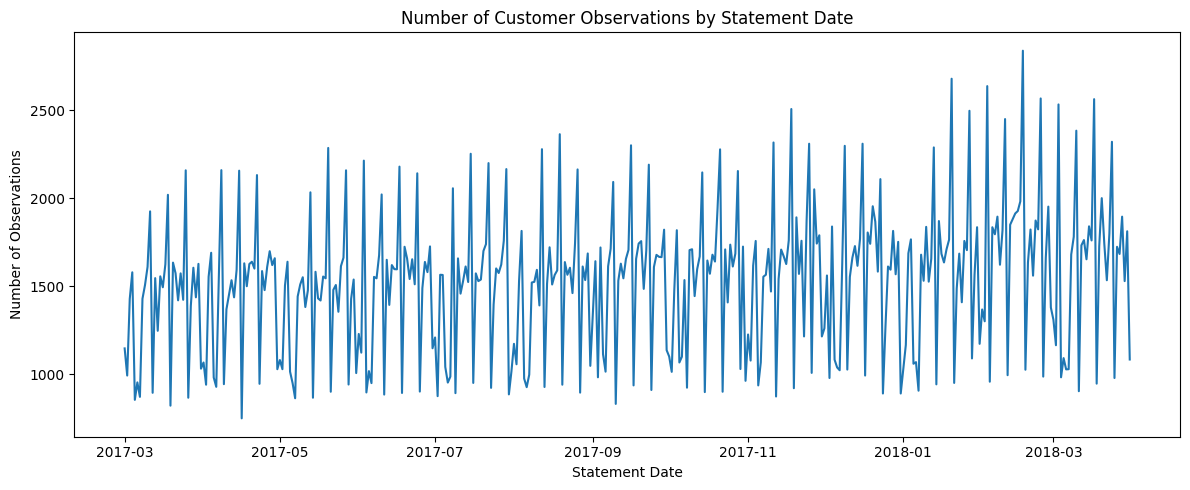

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(
    date_summary["S_2"],
    date_summary["observations"]
)

plt.xlabel("Statement Date")
plt.ylabel("Number of Observations")
plt.title("Number of Customer Observations by Statement Date")

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# EDA 5.2 — HISTORY LENGTH VS DEFAULT
# ============================================================

history_target = (
    dev_df.groupby("customer_ID")
    .agg(
        n_statements=("S_2", "nunique"),
        target=("target", "first")
    )
    .reset_index()
)

history_summary = (
    history_target
    .groupby("n_statements")
    .agg(
        customers=("customer_ID", "size"),
        defaults=("target", "sum"),
        default_rate=("target", "mean")
    )
    .reset_index()
)

history_summary["default_rate_pct"] = (
    history_summary["default_rate"] * 100
)

display(history_summary)

,n_statements,customers,defaults,default_rate,default_rate_pct
0,1,524,173,0.330153,33.015267
1,2,662,223,0.336858,33.685801
2,3,637,219,0.343799,34.379906
3,4,491,215,0.437882,43.788187
4,5,516,193,0.374031,37.403101
5,6,607,254,0.418451,41.845140
6,7,570,241,0.422807,42.280702
7,8,596,283,0.474832,47.483221
8,9,702,308,0.438746,43.874644
9,10,719,327,0.454798,45.479833


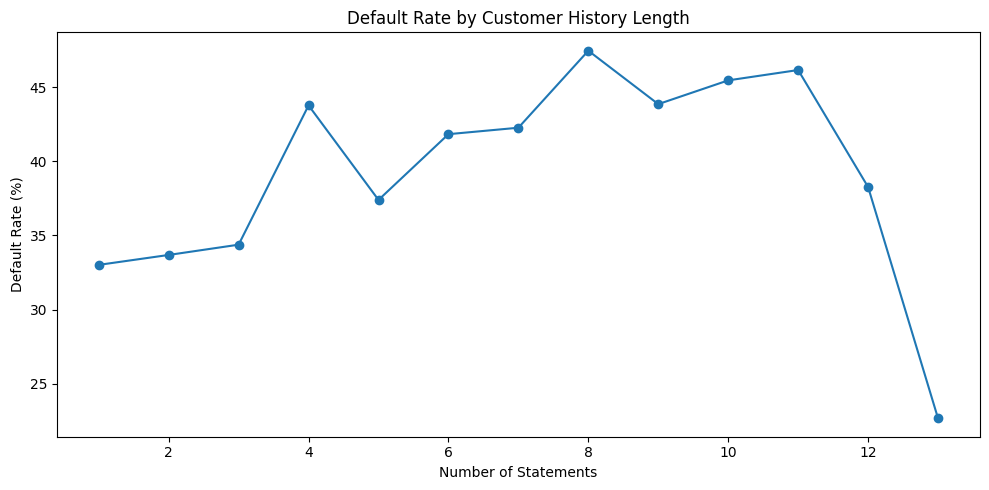

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_summary["n_statements"],
    history_summary["default_rate_pct"],
    marker="o"
)

plt.xlabel("Number of Statements")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Customer History Length")

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# EDA 5.3 — CUSTOMER-LEVEL GAP BEHAVIOR
# ============================================================

customer_gap_summary = []

for customer_id, group in dev_df.groupby("customer_ID"):

    dates = (
        group["S_2"]
        .drop_duplicates()
        .sort_values()
    )

    if len(dates) <= 1:
        customer_gap_summary.append({
            "customer_ID": customer_id,
            "n_statements": len(dates),
            "mean_gap_days": np.nan,
            "max_gap_days": np.nan,
            "n_large_gaps": 0
        })
        continue

    gaps = dates.diff().dt.days.dropna()

    customer_gap_summary.append({
        "customer_ID": customer_id,
        "n_statements": len(dates),
        "mean_gap_days": gaps.mean(),
        "max_gap_days": gaps.max(),
        "n_large_gaps": (gaps > 31).sum()
    })

customer_gap_df = pd.DataFrame(customer_gap_summary)

customer_gap_df = customer_gap_df.merge(
    customer_target,
    on="customer_ID",
    how="left"
)

display(customer_gap_df.head())

,customer_ID,n_statements,mean_gap_days,max_gap_days,n_large_gaps,target
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,13,30.500000,42.0,4,0
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,13,31.000000,38.0,4,0
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,13,30.500000,52.0,6,0
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,13,30.333333,51.0,6,0
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,13,31.083333,50.0,6,0


In [59]:
gap_target_summary = (
    customer_gap_df
    .groupby("target")
    .agg(
        customers=("customer_ID", "size"),
        mean_gap=("mean_gap_days", "mean"),
        median_gap=("mean_gap_days", "median"),
        mean_max_gap=("max_gap_days", "mean"),
        mean_large_gaps=("n_large_gaps", "mean")
    )
    .reset_index()
)

display(gap_target_summary)

,target,customers,mean_gap,median_gap,mean_max_gap,mean_large_gaps
0,0,37288,30.613203,30.416667,47.165065,3.925955
1,1,12712,30.443497,30.416667,48.557461,4.084015


In [60]:
history_features = [
    "P_2",
    "B_1",
    "B_2",
    "B_9",
    "D_42",
    "D_48",
    "D_61",
    "D_44",
    "D_55",
    "D_75"
]

In [61]:
# ============================================================
# EDA 5.4 — FIRST VS LATEST CUSTOMER STATE
# ============================================================

sorted_dev = dev_df.sort_values(
    ["customer_ID", "S_2"]
)

first_snapshot = (
    sorted_dev
    .groupby("customer_ID", sort=False)
    .head(1)
    .set_index("customer_ID")
)

latest_snapshot = (
    sorted_dev
    .groupby("customer_ID", sort=False)
    .tail(1)
    .set_index("customer_ID")
)

first_latest = pd.DataFrame(index=latest_snapshot.index)

for feature in history_features:

    first_latest[f"{feature}_first"] = (
        first_snapshot[feature]
    )

    first_latest[f"{feature}_latest"] = (
        latest_snapshot[feature]
    )

    first_latest[f"{feature}_change"] = (
        latest_snapshot[feature]
        - first_snapshot[feature]
    )

first_latest["target"] = latest_snapshot["target"]

display(first_latest.head())

,P_2_first,P_2_latest,P_2_change,B_1_first,B_1_latest,B_1_change,B_2_first,B_2_latest,B_2_change,B_9_first,...,D_44_first,D_44_latest,D_44_change,D_55_first,D_55_latest,D_55_change,D_75_first,D_75_latest,D_75_change,target
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0.374606,0.477116,0.102509,0.044293,0.009413,-0.034880,1.008622,1.009217,0.000596,0.506847,...,0.007022,0.002877,-0.004145,0.106543,0.268703,0.162160,0.143122,0.074141,-0.068980,0
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,0.993348,0.978897,-0.014451,0.003621,0.006584,0.002963,0.813298,0.819623,0.006325,0.020149,...,0.005743,0.008359,0.002616,0.080929,0.097834,0.016905,0.069071,0.000094,-0.068977,0
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0.712943,0.642295,-0.070648,0.569961,0.429796,-0.140165,0.058500,0.024450,-0.034050,0.600204,...,0.008741,0.132544,0.123802,0.248844,0.345840,0.096997,0.208821,0.334304,0.125483,0
0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704029f989240c733b6d0,0.966142,0.980221,0.014079,0.043060,0.028153,-0.014907,1.007691,1.008633,0.000942,0.001006,...,0.007606,0.004267,-0.003339,0.006107,0.014255,0.008148,0.008188,0.073315,0.065127,0
00050d84c6d26e26cd2b18c3eed83d3130c270e2361470ff272f9409103d067f,0.926323,1.006598,0.080276,0.015389,0.045083,0.029694,1.000006,1.005729,0.005723,0.048724,...,0.008459,0.009865,0.001406,0.068805,0.052235,-0.016569,0.006340,0.002978,-0.003362,0


In [62]:
change_summary = []

for feature in history_features:

    change_col = f"{feature}_change"

    temp = first_latest[
        [change_col, "target"]
    ].dropna()

    summary = (
        temp.groupby("target")[change_col]
        .agg(
            mean="mean",
            median="median",
            std="std"
        )
        .reset_index()
    )

    summary["feature"] = feature

    change_summary.append(summary)

change_summary = pd.concat(
    change_summary,
    ignore_index=True
)

display(change_summary)

,target,mean,median,std,feature
0,0,0.011418,0.009213,0.103631,P_2
1,1,-0.106870,-0.073705,0.179835,P_2
2,0,0.000814,0.000000,0.140397,B_1
3,1,0.107949,0.045847,0.252612,B_1
4,0,-0.007828,0.000000,0.308379,B_2
5,1,-0.234581,-0.032917,0.409716,B_2
6,0,0.002024,-0.000115,0.184116,B_9
7,1,0.150993,0.050455,0.338580,B_9
8,0,-0.010221,-0.003127,0.054183,D_42
9,1,-0.032488,-0.016022,0.100753,D_42


In [63]:
# ============================================================
# EDA 5.5 — CUSTOMER-LEVEL VOLATILITY
# ============================================================

volatility_features = [
    "P_2",
    "B_1",
    "B_2",
    "B_9",
    "D_42",
    "D_48",
    "D_61",
    "D_44",
    "D_55",
    "D_75"
]

volatility_df = (
    dev_df
    .groupby("customer_ID")[volatility_features]
    .agg(["mean", "std", "min", "max"])
)

# Flatten column names
volatility_df.columns = [
    f"{feature}_{stat}"
    for feature, stat in volatility_df.columns
]

volatility_df = volatility_df.reset_index()

volatility_df = volatility_df.merge(
    customer_target,
    on="customer_ID",
    how="left"
)

display(volatility_df.head())

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,B_1_mean,B_1_std,B_1_min,B_1_max,B_2_mean,...,D_44_max,D_55_mean,D_55_std,D_55_min,D_55_max,D_75_mean,D_75_std,D_75_min,D_75_max,target
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.444606,0.065085,0.328983,0.560474,0.070828,0.031472,0.009413,0.112638,0.247854,...,0.009452,0.193489,0.040245,0.106543,0.268703,0.158497,0.042151,0.074141,0.209879,0
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.972260,0.010865,0.949051,0.993348,0.005157,0.003589,0.000282,0.010821,0.816084,...,0.009462,0.104093,0.014690,0.080929,0.129645,0.008872,0.018376,0.000094,0.069071,0
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.665203,0.028379,0.628740,0.712943,0.494706,0.047802,0.429032,0.569961,0.047334,...,0.132544,0.287474,0.032541,0.248844,0.345840,0.240554,0.057981,0.201746,0.343131,0
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.970309,0.005252,0.963991,0.980221,0.040324,0.018582,0.019392,0.077360,1.006227,...,0.009879,0.010519,0.004204,0.005126,0.019386,0.025704,0.032355,0.000336,0.075869,0
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.953131,0.031159,0.918010,1.006598,0.032479,0.013414,0.011575,0.054590,0.820899,...,0.009865,0.062318,0.005881,0.052235,0.071805,0.015100,0.023523,0.002391,0.068960,0


In [64]:
volatility_summary = (
    volatility_df
    .groupby("target")["P_2_std"]
    .agg(
        customers="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

display(volatility_summary)

,target,customers,mean,median,std
0,0,36714,0.041234,0.032515,0.032787
1,1,12490,0.075983,0.062380,0.054123


In [65]:
# ============================================================
# EDA 5.6 — RECENT VS HISTORICAL BEHAVIOR
# ============================================================

recent_features = [
    "P_2",
    "B_1",
    "B_2",
    "B_9",
    "D_42",
    "D_48",
    "D_61",
    "D_44",
    "D_55",
    "D_75"
]

recent_data = (
    dev_df
    .sort_values(["customer_ID", "S_2"])
    .groupby("customer_ID")
    .tail(3)
)

recent_mean = (
    recent_data
    .groupby("customer_ID")[recent_features]
    .mean()
    .add_suffix("_recent_mean")
)

historical_mean = (
    dev_df
    .groupby("customer_ID")[recent_features]
    .mean()
    .add_suffix("_historical_mean")
)

recent_vs_history = (
    recent_mean
    .join(historical_mean)
    .reset_index()
    .merge(
        customer_target,
        on="customer_ID",
        how="left"
    )
)

for feature in recent_features:

    recent_vs_history[
        f"{feature}_recent_vs_history"
    ] = (
        recent_vs_history[f"{feature}_recent_mean"]
        -
        recent_vs_history[f"{feature}_historical_mean"]
    )

display(recent_vs_history.head())

,customer_ID,P_2_recent_mean,B_1_recent_mean,B_2_recent_mean,B_9_recent_mean,D_42_recent_mean,D_48_recent_mean,D_61_recent_mean,D_44_recent_mean,D_55_recent_mean,...,P_2_recent_vs_history,B_1_recent_vs_history,B_2_recent_vs_history,B_9_recent_vs_history,D_42_recent_vs_history,D_48_recent_vs_history,D_61_recent_vs_history,D_44_recent_vs_history,D_55_recent_vs_history,D_75_recent_vs_history
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.447802,0.069795,0.368671,0.575565,0.132976,0.475506,0.150140,0.005334,0.228723,...,0.003195,-0.001033,0.120817,-0.171529,-0.009431,0.082837,-0.232772,-0.000409,0.035233,-0.043732
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.976846,0.008831,0.815289,0.004837,NaN,0.079119,0.099297,0.003912,0.103029,...,0.004587,0.003674,-0.000795,-0.000761,NaN,-0.033692,-0.047427,-0.001097,-0.001064,-0.007940
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.638958,0.431032,0.049020,0.472014,NaN,0.427507,0.697476,0.128228,0.340063,...,-0.026245,-0.063674,0.001685,-0.048955,NaN,0.079237,0.242123,0.066160,0.052589,0.096909
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.973429,0.023506,1.009225,0.005654,NaN,0.005169,0.019730,0.006591,0.013157,...,0.003120,-0.016818,0.002998,-0.000511,NaN,-0.007516,0.006712,0.000438,0.002638,0.025404
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.993352,0.040335,0.881636,0.111082,NaN,0.078238,0.089054,0.005324,0.061246,...,0.040221,0.007856,0.060737,0.018746,NaN,0.015177,0.038334,-0.001088,-0.001071,-0.008568


In [66]:
recent_change_summary = []

for feature in recent_features:

    col = f"{feature}_recent_vs_history"

    temp = recent_vs_history[
        [col, "target"]
    ].dropna()

    summary = (
        temp.groupby("target")[col]
        .agg(
            mean="mean",
            median="median",
            std="std"
        )
        .reset_index()
    )

    summary["feature"] = feature

    recent_change_summary.append(summary)

recent_change_summary = pd.concat(
    recent_change_summary,
    ignore_index=True
)

display(recent_change_summary)

,target,mean,median,std,feature
0,0,0.002879,0.002608,0.048171,P_2
1,1,-0.047990,-0.028343,0.085910,P_2
2,0,0.000505,-0.000309,0.061184,B_1
3,1,0.041774,0.014025,0.111956,B_1
4,0,-0.004934,0.000000,0.131750,B_2
5,1,-0.081652,-0.021886,0.167155,B_2
6,0,-0.000677,-0.000224,0.083123,B_9
7,1,0.053084,0.014164,0.154763,B_9
8,0,-0.005598,-0.000911,0.029470,D_42
9,1,-0.018140,-0.008143,0.057165,D_42


In [68]:
# ============================================================
# Difference in recent-vs-history behavior
# ============================================================

comparison = []

for feature in recent_features:

    col = f"{feature}_recent_vs_history"

    temp = recent_vs_history[
        [col, "target"]
    ].dropna()

    rates = (
        temp.groupby("target")[col]
        .mean()
    )

    comparison.append({
        "feature": feature,
        "non_default_mean_change": rates.get(0, np.nan),
        "default_mean_change": rates.get(1, np.nan),
        "difference": (
            rates.get(1, np.nan)
            - rates.get(0, np.nan)
        )
    })

recent_vs_history_comparison = pd.DataFrame(comparison)

recent_vs_history_comparison = (
    recent_vs_history_comparison
    .sort_values(
        "difference",
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(recent_vs_history_comparison)

,feature,non_default_mean_change,default_mean_change,difference
2,B_2,-0.004934,-0.081652,-0.076718
8,D_55,0.007733,0.082122,0.074389
5,D_48,0.001801,0.058583,0.056782
7,D_44,0.001951,0.057634,0.055684
3,B_9,-0.000677,0.053084,0.053762
0,P_2,0.002879,-0.047990,-0.050868
6,D_61,0.000172,0.046739,0.046567
1,B_1,0.000505,0.041774,0.041268
9,D_75,0.001260,0.036611,0.035351
4,D_42,-0.005598,-0.018140,-0.012542


**Phase 3: Feature Engineering & Preprocessing**

In [8]:
print("dev_df exists:", "dev_df" in globals())

dev_df exists: True


In [9]:
target_check = (
    dev_df
    .groupby("customer_ID")["target"]
    .nunique()
)

print("Customers:", target_check.shape[0])
print("Customers with inconsistent target:",
      (target_check > 1).sum())

customer_target = (
    dev_df
    .groupby("customer_ID")["target"]
    .first()
    .reset_index()
)

print("\nCustomer-level target distribution:")
print(customer_target["target"].value_counts())

print("\nCustomer-level target proportion:")
print(customer_target["target"].value_counts(normalize=True))

Customers: 50000
Customers with inconsistent target: 0

Customer-level target distribution:
target
0    37288
1    12712
Name: count, dtype: int64

Customer-level target proportion:
target
0    0.74576
1    0.25424
Name: proportion, dtype: float64


In [10]:
prediction_point = (
    dev_df
    .groupby("customer_ID")
    .agg(
        prediction_date=("S_2", "max"),
        n_statements=("S_2", "nunique")
    )
    .reset_index()
)

prediction_point = prediction_point.merge(
    customer_target,
    on="customer_ID",
    how="left"
)

print(prediction_point.shape)

display(prediction_point.head())

(50000, 4)


,customer_ID,prediction_date,n_statements,target
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,2018-03-12,13,0
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,2018-03-17,13,0
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,2018-03-02,13,0
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,2018-03-08,13,0
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,2018-03-22,13,0


In [11]:
latest_dates = (
    dev_df
    .groupby("customer_ID")["S_2"]
    .max()
)

check_dates = (
    dev_df
    .groupby("customer_ID")["S_2"]
    .max()
    .reset_index(name="latest_date")
    .merge(
        prediction_point[["customer_ID", "prediction_date"]],
        on="customer_ID"
    )
)

print(
    "Prediction date mismatches:",
    (check_dates["latest_date"] != check_dates["prediction_date"]).sum()
)

Prediction date mismatches: 0


In [12]:
base_cols = ["customer_ID", "S_2", "target"]

customer_base = (
    dev_df[base_cols]
    .sort_values(["customer_ID", "S_2"])
    .drop_duplicates("customer_ID", keep="last")
    .reset_index(drop=True)
)

print("Customer-level base table shape:", customer_base.shape)
print("Unique customers:", customer_base["customer_ID"].nunique())

display(customer_base.head())

Customer-level base table shape: (50000, 3)
Unique customers: 50000


,customer_ID,S_2,target
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,2018-03-12,0
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,2018-03-17,0
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,2018-03-02,0
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,2018-03-08,0
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,2018-03-22,0


In [13]:
print("Duplicate customers:",
      customer_base["customer_ID"].duplicated().sum())

print("\nTarget distribution:")
print(customer_base["target"].value_counts())

print("\nPrediction date range:")
print(customer_base["S_2"].min(), "to", customer_base["S_2"].max())

Duplicate customers: 0

Target distribution:
target
0    37288
1    12712
Name: count, dtype: int64

Prediction date range:
2018-03-01 to 2018-03-31


In [14]:
BASE_PATH = "/kaggle/working/amex_customer_base.parquet"

customer_base.to_parquet(
    BASE_PATH,
    index=False
)

print("Saved:", BASE_PATH)

Saved: /kaggle/working/amex_customer_base.parquet


In [15]:
longitudinal_features = [
    "P_2", "B_1", "B_2", "B_9", "D_42",
    "D_48", "D_61", "D_44", "D_55", "D_75"
]

In [16]:
# 3.3A — LATEST-VALUE FEATURES
latest_cols = ["customer_ID", "S_2"] + longitudinal_features

# Sort only the required columns
latest_df = (
    dev_df[latest_cols]
    .sort_values(["customer_ID", "S_2"])
    .drop_duplicates("customer_ID", keep="last")
    .reset_index(drop=True)
)

# Rename feature columns
latest_df = latest_df.rename(
    columns={
        feature: f"{feature}_latest"
        for feature in longitudinal_features
    }
)

print("Latest-value table shape:", latest_df.shape)

display(latest_df.head())

Latest-value table shape: (50000, 12)


,customer_ID,S_2,P_2_latest,B_1_latest,B_2_latest,B_9_latest,D_42_latest,D_48_latest,D_61_latest,D_44_latest,D_55_latest,D_75_latest
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,2018-03-12,0.477116,0.009413,1.009217,0.014493,NaN,0.676813,0.106100,0.002877,0.268703,0.074141
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,2018-03-17,0.978897,0.006584,0.819623,0.007358,NaN,0.040392,0.115288,0.008359,0.097834,0.000094
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,2018-03-02,0.642295,0.429796,0.024450,0.476559,NaN,0.427455,1.300325,0.132544,0.345840,0.334304
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,2018-03-08,0.980221,0.028153,1.008633,0.007583,NaN,0.009795,0.018627,0.004267,0.014255,0.073315
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,2018-03-22,1.006598,0.045083,1.005729,0.128710,NaN,0.036011,0.049851,0.009865,0.052235,0.002978


In [17]:
print(
    "Duplicate customers:",
    latest_df["customer_ID"].duplicated().sum()
)

Duplicate customers: 0


In [18]:
customer_features = customer_base.merge(
    latest_df,
    on="customer_ID",
    how="left"
)

print("Customer feature table:", customer_features.shape)
print("Unique customers:", customer_features["customer_ID"].nunique())

Customer feature table: (50000, 14)
Unique customers: 50000


In [19]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3A.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3A.parquet


In [20]:
# 3.3B — HISTORICAL STATISTICS
historical_cols = ["customer_ID"] + longitudinal_features

historical_stats = (
    dev_df[historical_cols]
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .agg(["mean", "median", "min", "max"])
)

# Flatten MultiIndex column names
historical_stats.columns = [
    f"{feature}_hist_{stat}"
    for feature, stat in historical_stats.columns
]

historical_stats = historical_stats.reset_index()

print("Historical statistics shape:", historical_stats.shape)

display(historical_stats.head())

Historical statistics shape: (50000, 41)


,customer_ID,P_2_hist_mean,P_2_hist_median,P_2_hist_min,P_2_hist_max,B_1_hist_mean,B_1_hist_median,B_1_hist_min,B_1_hist_max,B_2_hist_mean,...,D_44_hist_min,D_44_hist_max,D_55_hist_mean,D_55_hist_median,D_55_hist_min,D_55_hist_max,D_75_hist_mean,D_75_hist_median,D_75_hist_min,D_75_hist_max
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.444606,0.414444,0.328983,0.560474,0.070828,0.061001,0.009413,0.112638,0.247854,...,0.002636,0.009452,0.193489,0.200589,0.106543,0.268703,0.158497,0.139503,0.074141,0.209879
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.972260,0.972036,0.949051,0.993348,0.005157,0.004770,0.000282,0.010821,0.816084,...,0.000895,0.009462,0.104093,0.104235,0.080929,0.129645,0.008872,0.002524,0.000094,0.069071
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.665203,0.663800,0.628740,0.712943,0.494706,0.494838,0.429032,0.569961,0.047334,...,0.001399,0.132544,0.287474,0.273793,0.248844,0.345840,0.240554,0.208821,0.201746,0.343131
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.970309,0.967569,0.963991,0.980221,0.040324,0.038809,0.019392,0.077360,1.006227,...,0.000984,0.009879,0.010519,0.009729,0.005126,0.019386,0.025704,0.008188,0.000336,0.075869
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.953131,0.944296,0.918010,1.006598,0.032479,0.032610,0.011575,0.054590,0.820899,...,0.000968,0.009865,0.062318,0.061403,0.052235,0.071805,0.015100,0.006340,0.002391,0.068960


In [21]:
customer_features = customer_features.merge(
    historical_stats,
    on="customer_ID",
    how="left"
)

print("Updated customer feature table:", customer_features.shape)

Updated customer feature table: (50000, 54)


In [22]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3B.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3B.parquet


In [23]:
# 3.3C — FIRST-TO-LATEST CHANGE FEATURES
change_cols = ["customer_ID", "S_2"] + longitudinal_features

# Sort chronologically
change_data = (
    dev_df[change_cols]
    .sort_values(["customer_ID", "S_2"])
)

# First observed value
first_values = (
    change_data
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .first()
    .add_suffix("_first")
    .reset_index()
)

# Latest observed value
latest_values = (
    change_data
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .last()
    .add_suffix("_latest_check")
    .reset_index()
)

# Calculate first-to-latest change
change_features = first_values.copy()

for feature in longitudinal_features:
    change_features[f"{feature}_change"] = (
        latest_values[f"{feature}_latest_check"]
        - first_values[f"{feature}_first"]
    )

# Keep only customer ID + change features
change_features = change_features[
    ["customer_ID"] +
    [f"{feature}_change" for feature in longitudinal_features]
]

print("First-to-latest change table shape:", change_features.shape)

display(change_features.head())

First-to-latest change table shape: (50000, 11)


,customer_ID,P_2_change,B_1_change,B_2_change,B_9_change,D_42_change,D_48_change,D_61_change,D_44_change,D_55_change,D_75_change
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.102509,-0.034880,0.000596,-0.492355,-0.019956,0.039466,-0.595798,-0.004145,0.162160,-0.068980
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,-0.014451,0.002963,0.006325,-0.012791,NaN,-0.096720,-0.354682,0.002616,0.016905,-0.068977
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,-0.070648,-0.140165,-0.034050,-0.123644,NaN,0.126672,0.994266,0.123802,0.096997,0.125483
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.014079,-0.014907,0.000942,0.006577,NaN,0.007820,0.011315,-0.003339,0.008148,0.065127
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.080276,0.029694,0.005723,0.079987,NaN,0.000892,0.016035,0.001406,-0.016569,-0.003362


In [24]:
customer_features = customer_features.merge(
    change_features,
    on="customer_ID",
    how="left"
)

print("Updated feature table:", customer_features.shape)

Updated feature table: (50000, 64)


In [25]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3C.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3C.parquet


In [26]:
#3.3D — HISTORICAL VOLATILITY FEATURES
volatility_features = (
    dev_df[["customer_ID"] + longitudinal_features]
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .std()
    .add_suffix("_hist_std")
    .reset_index()
)

print("Volatility table shape:", volatility_features.shape)

display(volatility_features.head())

Volatility table shape: (50000, 11)


,customer_ID,P_2_hist_std,B_1_hist_std,B_2_hist_std,B_9_hist_std,D_42_hist_std,D_48_hist_std,D_61_hist_std,D_44_hist_std,D_55_hist_std,D_75_hist_std
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.065085,0.031472,0.344938,0.387021,0.009691,0.222910,0.209383,0.002286,0.040245,0.042151
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.010865,0.003589,0.002992,0.005343,NaN,0.032765,0.107852,0.002788,0.014690,0.018376
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.028379,0.047802,0.011897,0.044763,NaN,0.054221,0.255440,0.064463,0.032541,0.057981
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.005252,0.018582,0.002925,0.002815,NaN,0.014054,0.011100,0.003148,0.004204,0.032355
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.031159,0.013414,0.369694,0.034093,NaN,0.041888,0.027646,0.003126,0.005881,0.023523


In [27]:
customer_features = customer_features.merge(
    volatility_features,
    on="customer_ID",
    how="left"
)

print("Updated feature table:", customer_features.shape)

Updated feature table: (50000, 74)


In [29]:
print("Rows:", len(customer_features))
print("Customers:", customer_features["customer_ID"].nunique())

Rows: 50000
Customers: 50000


In [30]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3D.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3D.parquet


In [31]:
# 3.3E — RECENT 3-STATEMENT FEATURES
# ============================================================

recent_cols = ["customer_ID", "S_2"] + longitudinal_features

recent_data = (
    dev_df[recent_cols]
    .sort_values(["customer_ID", "S_2"])
)

# Take the latest 3 observations for each customer
recent_3 = (
    recent_data
    .groupby("customer_ID", sort=False)
    .tail(3)
)

# Calculate mean across the latest 3 statements
recent_features = (
    recent_3
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .mean()
    .add_suffix("_recent_mean")
    .reset_index()
)

print("Recent 3-statement table shape:", recent_features.shape)

display(recent_features.head())

Recent 3-statement table shape: (50000, 11)


,customer_ID,P_2_recent_mean,B_1_recent_mean,B_2_recent_mean,B_9_recent_mean,D_42_recent_mean,D_48_recent_mean,D_61_recent_mean,D_44_recent_mean,D_55_recent_mean,D_75_recent_mean
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.447802,0.069795,0.368671,0.575565,0.132976,0.475506,0.150140,0.005334,0.228723,0.114765
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.976846,0.008831,0.815289,0.004837,NaN,0.079119,0.099297,0.003912,0.103029,0.000932
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.638958,0.431032,0.049020,0.472014,NaN,0.427507,0.697476,0.128228,0.340063,0.337462
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.973429,0.023506,1.009225,0.005654,NaN,0.005169,0.019730,0.006591,0.013157,0.051108
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.993352,0.040335,0.881636,0.111082,NaN,0.078238,0.089054,0.005324,0.061246,0.006532


In [32]:
customer_features = customer_features.merge(
    recent_features,
    on="customer_ID",
    how="left"
)

print("Updated feature table:", customer_features.shape)

Updated feature table: (50000, 84)


In [33]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3E.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3E.parquet


In [34]:
# 3.3F — RECENT VS HISTORICAL FEATURES
for feature in longitudinal_features:

    recent_col = f"{feature}_recent_mean"
    historical_col = f"{feature}_hist_mean"
    change_col = f"{feature}_recent_vs_history"

    customer_features[change_col] = (
        customer_features[recent_col]
        - customer_features[historical_col]
    )

recent_history_cols = [
    f"{feature}_recent_vs_history"
    for feature in longitudinal_features
]

print("Number of recent-vs-history features:",
      len(recent_history_cols))

display(
    customer_features[
        ["customer_ID"] + recent_history_cols
    ].head()
)

Number of recent-vs-history features: 10


,customer_ID,P_2_recent_vs_history,B_1_recent_vs_history,B_2_recent_vs_history,B_9_recent_vs_history,D_42_recent_vs_history,D_48_recent_vs_history,D_61_recent_vs_history,D_44_recent_vs_history,D_55_recent_vs_history,D_75_recent_vs_history
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.003195,-0.001033,0.120817,-0.171529,-0.009431,0.082837,-0.232772,-0.000409,0.035233,-0.043732
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.004587,0.003674,-0.000795,-0.000761,NaN,-0.033692,-0.047427,-0.001097,-0.001064,-0.007940
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,-0.026245,-0.063674,0.001685,-0.048955,NaN,0.079237,0.242123,0.066160,0.052589,0.096909
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.003120,-0.016818,0.002998,-0.000511,NaN,-0.007516,0.006712,0.000438,0.002638,0.025404
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.040221,0.007856,0.060737,0.018746,NaN,0.015177,0.038334,-0.001088,-0.001071,-0.008568


In [35]:
print("Columns:", customer_features.shape[1])

Columns: 94


In [36]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3F.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3F.parquet


In [37]:
# 3.3G — CUSTOMER-LEVEL MISSINGNESS / HISTORY FEATURES
missing_cols = ["customer_ID"] + longitudinal_features

missing_history = (
    dev_df[missing_cols]
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .agg(
        lambda x: x.isna().mean()
    )
)

# Rename to missing percentage
missing_history.columns = [
    f"{feature}_hist_missing_pct"
    for feature in longitudinal_features
]

missing_history = missing_history.reset_index()

print("Missingness percentage table:", missing_history.shape)

display(missing_history.head())

Missingness percentage table: (50000, 11)


,customer_ID,P_2_hist_missing_pct,B_1_hist_missing_pct,B_2_hist_missing_pct,B_9_hist_missing_pct,D_42_hist_missing_pct,D_48_hist_missing_pct,D_61_hist_missing_pct,D_44_hist_missing_pct,D_55_hist_missing_pct,D_75_hist_missing_pct
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.0,0.0,0.0,0.0,0.153846,0.0,0.0,0.0,0.0,0.0
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0


In [38]:
# Missing observation count
missing_count = (
    dev_df[missing_cols]
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .apply(lambda x: x.isna().sum())
)

missing_count.columns = [
    f"{feature}_hist_missing_count"
    for feature in longitudinal_features
]

missing_count = missing_count.reset_index()


# Valid observation count
valid_count = (
    dev_df[missing_cols]
    .groupby("customer_ID", sort=False)[longitudinal_features]
    .count()
)

valid_count.columns = [
    f"{feature}_hist_valid_count"
    for feature in longitudinal_features
]

valid_count = valid_count.reset_index()

In [39]:
missing_features = (
    missing_history
    .merge(missing_count, on="customer_ID")
    .merge(valid_count, on="customer_ID")
)

print("Missingness/history table:", missing_features.shape)

display(missing_features.head())

Missingness/history table: (50000, 31)


,customer_ID,P_2_hist_missing_pct,B_1_hist_missing_pct,B_2_hist_missing_pct,B_9_hist_missing_pct,D_42_hist_missing_pct,D_48_hist_missing_pct,D_61_hist_missing_pct,D_44_hist_missing_pct,D_55_hist_missing_pct,...,P_2_hist_valid_count,B_1_hist_valid_count,B_2_hist_valid_count,B_9_hist_valid_count,D_42_hist_valid_count,D_48_hist_valid_count,D_61_hist_valid_count,D_44_hist_valid_count,D_55_hist_valid_count,D_75_hist_valid_count
0,000098081fde4fd64bc4d503a5d6f86a0aedc425c96f52...,0.0,0.0,0.0,0.0,0.153846,0.0,0.0,0.0,0.0,...,13,13,13,13,11,13,13,13,13,13
1,000445609ff2a39d2dd02484899affa5696210a95f6869...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,...,13,13,13,13,0,13,13,13,13,13
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,...,13,13,13,13,0,13,13,13,13,13
3,0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,...,13,13,13,13,0,13,13,13,13,13
4,00050d84c6d26e26cd2b18c3eed83d3130c270e2361470...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,...,13,13,13,13,0,13,13,13,13,13


In [40]:
customer_features = customer_features.merge(
    missing_features,
    on="customer_ID",
    how="left"
)

print("Final longitudinal feature table:", customer_features.shape)

Final longitudinal feature table: (50000, 124)


In [41]:
FEATURE_PATH = "/kaggle/working/amex_features_2_3G.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_3G.parquet


**3.4 — Missing-Value Treatment**

In [42]:
missing_summary = (
    customer_features
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_pct")
)

missing_summary["missing_count"] = (
    customer_features.isna().sum()
)

display(missing_summary.head(30))

,missing_pct,missing_count
D_42_latest,87.284,43642
D_42_recent_vs_history,85.054,42527
D_42_recent_mean,85.054,42527
D_42_hist_std,77.102,38551
D_42_hist_min,75.460,37730
D_42_change,75.460,37730
D_42_hist_mean,75.460,37730
D_42_hist_median,75.460,37730
D_42_hist_max,75.460,37730
D_48_latest,12.658,6329


In [43]:
print("Total features:", customer_features.shape[1])
print("Features with missing values:",
      (missing_summary["missing_pct"] > 0).sum())
print("Features >50% missing:",
      (missing_summary["missing_pct"] > 50).sum())
print("Features >90% missing:",
      (missing_summary["missing_pct"] > 90).sum())

Total features: 124
Features with missing values: 66
Features >50% missing: 9
Features >90% missing: 0


In [44]:

# 2.4B — IDENTIFY HIGH-MISSINGNESS FEATURES

high_missing = (
    missing_summary[
        missing_summary["missing_pct"] > 50
    ]
    .sort_values("missing_pct", ascending=False)
)

display(high_missing)

,missing_pct,missing_count
D_42_latest,87.284,43642
D_42_recent_vs_history,85.054,42527
D_42_recent_mean,85.054,42527
D_42_hist_std,77.102,38551
D_42_hist_min,75.460,37730
D_42_change,75.460,37730
D_42_hist_mean,75.460,37730
D_42_hist_median,75.460,37730
D_42_hist_max,75.460,37730


In [45]:
#Drop D42
d42_features = [
    col for col in customer_features.columns
    if col.startswith("D_42_")
]

print("D_42 features to drop:")
print(d42_features)

customer_features = customer_features.drop(
    columns=d42_features
)

print("\nUpdated shape:", customer_features.shape)

D_42 features to drop:
['D_42_latest', 'D_42_hist_mean', 'D_42_hist_median', 'D_42_hist_min', 'D_42_hist_max', 'D_42_change', 'D_42_hist_std', 'D_42_recent_mean', 'D_42_recent_vs_history', 'D_42_hist_missing_pct', 'D_42_hist_missing_count', 'D_42_hist_valid_count']

Updated shape: (50000, 112)


In [46]:
FEATURE_PATH = "/kaggle/working/amex_features_2_4C.parquet"

customer_features.to_parquet(
    FEATURE_PATH,
    index=False
)

print("Saved:", FEATURE_PATH)

Saved: /kaggle/working/amex_features_2_4C.parquet


In [47]:
# 2.4D — CUSTOMER-LEVEL TRAIN / VALIDATION SPLIT

from sklearn.model_selection import train_test_split

# Customer IDs only
customer_ids = customer_features["customer_ID"]

train_ids, valid_ids = train_test_split(
    customer_ids,
    test_size=0.20,
    random_state=42,
    stratify=customer_features["target"]
)

train_df = customer_features[
    customer_features["customer_ID"].isin(train_ids)
].copy()

valid_df = customer_features[
    customer_features["customer_ID"].isin(valid_ids)
].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

print("\nTrain customers:", train_df["customer_ID"].nunique())
print("Validation customers:", valid_df["customer_ID"].nunique())

print("\nTrain target:")
print(train_df["target"].value_counts(normalize=True))

print("\nValidation target:")
print(valid_df["target"].value_counts(normalize=True))

Train shape: (40000, 112)
Validation shape: (10000, 112)

Train customers: 40000
Validation customers: 10000

Train target:
target
0    0.74575
1    0.25425
Name: proportion, dtype: float64

Validation target:
target
0    0.7458
1    0.2542
Name: proportion, dtype: float64


In [48]:
# ============================================================
# 2.4E — MEDIAN IMPUTATION
# ============================================================

from sklearn.impute import SimpleImputer

# Separate target
y_train = train_df["target"]
y_valid = valid_df["target"]

# Select only numerical columns
numeric_cols = train_df.select_dtypes(
    include=["number"]
).columns.tolist()

# Remove target from predictors
numeric_cols.remove("target")

X_train = train_df[numeric_cols].copy()
X_valid = valid_df[numeric_cols].copy()

print("Numerical features:", len(numeric_cols))
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

# Fit ONLY on training data
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=numeric_cols,
    index=X_train.index
)

X_valid_imp = pd.DataFrame(
    imputer.transform(X_valid),
    columns=numeric_cols,
    index=X_valid.index
)

print("\nMissing values after imputation:")
print("Train:", X_train_imp.isna().sum().sum())
print("Validation:", X_valid_imp.isna().sum().sum())

Numerical features: 108
X_train: (40000, 108)
X_valid: (10000, 108)

Missing values after imputation:
Train: 0
Validation: 0


**3.5 — Categorical/discrete treatment**

In [49]:
# 2.5A — IDENTIFY CATEGORICAL / NON-NUMERIC FEATURES

non_numeric_cols = train_df.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Non-numeric columns:")
for col in non_numeric_cols:
    print(
        f"{col:<30} | "
        f"dtype = {train_df[col].dtype} | "
        f"unique = {train_df[col].nunique(dropna=False)}"
    )

Non-numeric columns:
customer_ID                    | dtype = object | unique = 40000
S_2_x                          | dtype = object | unique = 31
S_2_y                          | dtype = object | unique = 31


In [50]:
for col in non_numeric_cols:
    print("\n" + "=" * 60)
    print("FEATURE:", col)
    print(train_df[col].value_counts(dropna=False).head(10))


FEATURE: customer_ID
customer_ID
ffed3d637bd646af55020b2c5c8c42b399d422f04f49edcf24e4d46bbab65486    1
ffe91e4fea805cb0d8674ed37446fecdf1e57cf8d6d4c5bce541b88b3c673c3a    1
ffe77187e738b50bfb8c86d25f9db82f7b3597e85f1fd5a1ebd155545b6312a6    1
ffddf52e8ca1429b2a97f85880bd472a03be2e6307b65b633d6a7070ac41331d    1
ffdd7e0f5c8e51f78abf100c6a11332c1f47bdae9c79a80a122ce43192bfcf00    1
ffdb6f657cb944f97cba8cb88884d735e422a3dc68eeb8fd02aa6f2562fb8712    1
ffd845adafb6637a33a39d379657daded8a0a8a45e22302ec93df77eef515d49    1
ffd7060d7bccdbd33b93955f3d4f65b8c0063d46888ad7437515f38ae1a16ff7    1
ffd6a301b0f94dec47dda9fec844cdc640a04bb38e8707a3e10fd9dc09069d3d    1
ffd3af67a0867979d57642b12bb0b04d9141347b8ad6d3f0041db9562fd8a06e    1
Name: count, dtype: int64

FEATURE: S_2_x
S_2_x
2018-03-17    2051
2018-03-03    1978
2018-03-10    1960
2018-03-24    1846
2018-03-20    1606
2018-03-28    1521
2018-03-15    1476
2018-03-30    1460
2018-03-23    1447
2018-03-16    1430
Name: count, dtype: int64

F

In [51]:
# 2.5B — REMOVE NON-MODEL COLUMNS

non_model_cols = [
    "customer_ID",
    "S_2_x",
    "S_2_y"
]

train_model = train_df.drop(
    columns=non_model_cols,
    errors="ignore"
).copy()

valid_model = valid_df.drop(
    columns=non_model_cols,
    errors="ignore"
).copy()

print("Train shape:", train_model.shape)
print("Validation shape:", valid_model.shape)

print("\nRemaining non-numeric columns:")
print(
    train_model.select_dtypes(exclude=["number"]).columns.tolist()
)

Train shape: (40000, 109)
Validation shape: (10000, 109)

Remaining non-numeric columns:
[]


In [52]:
y_train = train_model["target"]
y_valid = valid_model["target"]

X_train_raw = train_model.drop(columns=["target"])
X_valid_raw = valid_model.drop(columns=["target"])

print("X_train:", X_train_raw.shape)
print("X_valid:", X_valid_raw.shape)

X_train: (40000, 108)
X_valid: (10000, 108)


**3.6 — Feature selection / remove unsuitable features**

In [53]:
# ============================================================
# 2.6A — CONSTANT / NEAR-CONSTANT FEATURE CHECK
# ============================================================

import numpy as np
import pandas as pd

# Start from the already-imputed training data
X_fs = X_train_imp.copy()

print("Starting features:", X_fs.shape[1])

# ------------------------------------------------------------
# 1. Constant features
# ------------------------------------------------------------

constant_features = [
    col for col in X_fs.columns
    if X_fs[col].nunique(dropna=False) <= 1
]

print("\nConstant features:", len(constant_features))
print(constant_features)

# ------------------------------------------------------------
# 2. Near-constant features
#    Remove if one value occurs >= 99.5% of the time
# ------------------------------------------------------------

near_constant_features = []

for col in X_fs.columns:
    if col in constant_features:
        continue

    top_frequency = X_fs[col].value_counts(
        normalize=True
    ).iloc[0]

    if top_frequency >= 0.995:
        near_constant_features.append(col)

print("\nNear-constant features:", len(near_constant_features))
print(near_constant_features)

Starting features: 108

Constant features: 6
['B_1_hist_missing_pct', 'B_9_hist_missing_pct', 'D_75_hist_missing_pct', 'B_1_hist_missing_count', 'B_9_hist_missing_count', 'D_75_hist_missing_count']

Near-constant features: 2
['B_2_hist_missing_pct', 'B_2_hist_missing_count']


In [54]:
# Remove unsuitable constant / near-constant features

remove_low_variance = (
    constant_features +
    near_constant_features
)

X_train_fs = X_train_imp.drop(
    columns=remove_low_variance,
    errors="ignore"
)

X_valid_fs = X_valid_imp.drop(
    columns=remove_low_variance,
    errors="ignore"
)

print("\nAfter low-variance removal:")
print("Train:", X_train_fs.shape)
print("Validation:", X_valid_fs.shape)


After low-variance removal:
Train: (40000, 100)
Validation: (10000, 100)


In [55]:
# ============================================================
# 2.6B — CORRELATION FILTERING
# ============================================================

# Correlation matrix from TRAINING DATA ONLY
corr_matrix = X_train_fs.corr().abs()

# Keep only the upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features having correlation > 0.95 with another feature
high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Starting features:", X_train_fs.shape[1])
print("Highly correlated features:", len(high_corr_features))

print("\nFeatures identified for removal:")
print(high_corr_features)

Starting features: 100
Highly correlated features: 32

Features identified for removal:
['P_2_hist_mean', 'P_2_hist_median', 'P_2_hist_min', 'P_2_hist_max', 'B_1_hist_median', 'B_2_hist_median', 'B_9_hist_median', 'D_48_hist_median', 'D_61_hist_median', 'D_44_hist_median', 'D_55_hist_median', 'D_55_hist_max', 'D_75_hist_mean', 'D_75_hist_median', 'D_75_hist_min', 'D_75_hist_max', 'P_2_recent_mean', 'B_1_recent_mean', 'B_9_recent_mean', 'D_48_recent_mean', 'D_61_recent_mean', 'D_44_recent_mean', 'D_55_recent_mean', 'D_75_recent_mean', 'D_55_recent_vs_history', 'D_48_hist_missing_count', 'D_61_hist_missing_count', 'D_44_hist_missing_count', 'B_1_hist_valid_count', 'B_2_hist_valid_count', 'B_9_hist_valid_count', 'D_75_hist_valid_count']


In [56]:
# Show the strongest correlation pairs

corr_pairs = (
    upper.stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

corr_pairs = (
    corr_pairs[corr_pairs["correlation"] > 0.95]
    .sort_values("correlation", ascending=False)
)

display(corr_pairs.head(30))

,feature_1,feature_2,correlation
4928,B_1_hist_valid_count,D_75_hist_valid_count,1.000000
4923,B_1_hist_valid_count,B_9_hist_valid_count,1.000000
4939,B_9_hist_valid_count,D_75_hist_valid_count,1.000000
4922,B_1_hist_valid_count,B_2_hist_valid_count,0.999740
4929,B_2_hist_valid_count,B_9_hist_valid_count,0.999740
4934,B_2_hist_valid_count,D_75_hist_valid_count,0.999740
2997,D_55_hist_mean,D_55_hist_median,0.997905
734,D_55_latest,D_55_recent_mean,0.995760
3239,D_75_hist_mean,D_75_hist_median,0.994553
855,P_2_hist_mean,P_2_hist_median,0.994302


In [57]:
# ============================================================
# 2.6B — REVIEW CORRELATED FEATURE PAIRS
# ============================================================

# Show ALL pairs above the 0.95 threshold
all_high_corr_pairs = (
    corr_pairs[corr_pairs["correlation"] > 0.95]
    .sort_values("correlation", ascending=False)
)

print("Number of highly correlated pairs:",
      len(all_high_corr_pairs))

display(all_high_corr_pairs)

Number of highly correlated pairs: 51


,feature_1,feature_2,correlation
4928,B_1_hist_valid_count,D_75_hist_valid_count,1.000000
4923,B_1_hist_valid_count,B_9_hist_valid_count,1.000000
4939,B_9_hist_valid_count,D_75_hist_valid_count,1.000000
4922,B_1_hist_valid_count,B_2_hist_valid_count,0.999740
4929,B_2_hist_valid_count,B_9_hist_valid_count,0.999740
4934,B_2_hist_valid_count,D_75_hist_valid_count,0.999740
2997,D_55_hist_mean,D_55_hist_median,0.997905
734,D_55_latest,D_55_recent_mean,0.995760
3239,D_75_hist_mean,D_75_hist_median,0.994553
855,P_2_hist_mean,P_2_hist_median,0.994302


In [58]:
# ============================================================
# 2.6B — CONSERVATIVE CORRELATION FILTER
# ============================================================

correlation_drop_list = [
    # Redundant historical medians
    "P_2_hist_median",
    "B_1_hist_median",
    "B_2_hist_median",
    "B_9_hist_median",
    "D_48_hist_median",
    "D_61_hist_median",
    "D_44_hist_median",
    "D_55_hist_median",
    "D_75_hist_median",

    # Redundant historical extrema
    "P_2_hist_min",
    "P_2_hist_max",
    "D_55_hist_max",
    "D_75_hist_min",
    "D_75_hist_max",

    # Recent mean highly redundant with latest
    "P_2_recent_mean",
    "B_1_recent_mean",
    "B_9_recent_mean",
    "D_48_recent_mean",
    "D_61_recent_mean",
    "D_44_recent_mean",
    "D_55_recent_mean",
    "D_75_recent_mean",

    # Redundant change representation
    "D_55_recent_vs_history",

    # Missing count duplicates missing percentage
    "D_48_hist_missing_count",
    "D_61_hist_missing_count",
    "D_44_hist_missing_count",

    # Valid counts are highly redundant with each other/history
    "B_1_hist_valid_count",
    "B_2_hist_valid_count",
    "B_9_hist_valid_count",
    "D_75_hist_valid_count",
]

# Apply to both train and validation
X_train_selected = X_train_fs.drop(
    columns=correlation_drop_list,
    errors="ignore"
)

X_valid_selected = X_valid_fs.drop(
    columns=correlation_drop_list,
    errors="ignore"
)

print("Before correlation filtering:",
      X_train_fs.shape[1])

print("Requested removals:",
      len(correlation_drop_list))

print("After correlation filtering:",
      X_train_selected.shape[1])

print("Train shape:", X_train_selected.shape)
print("Validation shape:", X_valid_selected.shape)

Before correlation filtering: 100
Requested removals: 30
After correlation filtering: 70
Train shape: (40000, 70)
Validation shape: (10000, 70)


**3.7 — Class-imbalance handling**

In [59]:
# 3.7A — CLASS IMBALANCE

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

print("Class distribution:")
print(y_train.value_counts())

print("\nClass proportions:")
print(y_train.value_counts(normalize=True))

print("\nBalanced class weights:")
print(class_weight_dict)

Class distribution:
target
0    29830
1    10170
Name: count, dtype: int64

Class proportions:
target
0    0.74575
1    0.25425
Name: proportion, dtype: float64

Balanced class weights:
{np.int64(0): np.float64(0.670465973851827), np.int64(1): np.float64(1.966568338249754)}


**4.Model Development**

**4.1 Logistic Regression**

In [60]:
# ============================================================
# 4.1A — FEATURE SCALING FOR LOGISTIC REGRESSION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_selected),
    columns=X_train_selected.columns,
    index=X_train_selected.index
)

# Apply same transformation to validation
X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid_selected),
    columns=X_valid_selected.columns,
    index=X_valid_selected.index
)

print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_valid_scaled.shape)

print("\nTraining mean (first 5 features):")
print(X_train_scaled.iloc[:, :5].mean().round(4))

print("\nTraining std (first 5 features):")
print(X_train_scaled.iloc[:, :5].std().round(4))

Training shape: (40000, 70)
Validation shape: (10000, 70)

Training mean (first 5 features):
P_2_latest     0.0
B_1_latest     0.0
B_2_latest     0.0
B_9_latest    -0.0
D_48_latest   -0.0
dtype: float64

Training std (first 5 features):
P_2_latest     1.0
B_1_latest     1.0
B_2_latest     1.0
B_9_latest     1.0
D_48_latest    1.0
dtype: float64


In [61]:

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)

# Fit on training data only
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression fitted successfully.")
print("Number of coefficients:", len(logistic_model.coef_[0]))

Logistic Regression fitted successfully.
Number of coefficients: 70


In [62]:
# Model Evaluation 
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Validation probabilities
y_valid_proba_lr = logistic_model.predict_proba(
    X_valid_scaled
)[:, 1]

# Default threshold = 0.50
y_valid_pred_lr = (
    y_valid_proba_lr >= 0.50
).astype(int)

# Metrics
roc_auc_lr = roc_auc_score(
    y_valid,
    y_valid_proba_lr
)

pr_auc_lr = average_precision_score(
    y_valid,
    y_valid_proba_lr
)

precision_lr = precision_score(
    y_valid,
    y_valid_pred_lr
)

recall_lr = recall_score(
    y_valid,
    y_valid_pred_lr
)

f1_lr = f1_score(
    y_valid,
    y_valid_pred_lr
)

cm_lr = confusion_matrix(
    y_valid,
    y_valid_pred_lr
)

print("===== LOGISTIC REGRESSION — VALIDATION =====")
print(f"ROC-AUC : {roc_auc_lr:.4f}")
print(f"PR-AUC  : {pr_auc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

print("\nConfusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_valid_pred_lr,
        digits=4
    )
)

===== LOGISTIC REGRESSION — VALIDATION =====
ROC-AUC : 0.9385
PR-AUC  : 0.8328
Precision: 0.6663
Recall   : 0.8922
F1-score : 0.7629

Confusion Matrix:
[[6322 1136]
 [ 274 2268]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9585    0.8477    0.8997      7458
           1     0.6663    0.8922    0.7629      2542

    accuracy                         0.8590     10000
   macro avg     0.8124    0.8699    0.8313     10000
weighted avg     0.8842    0.8590    0.8649     10000



**4.2 Random Forest**

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_selected,
    y_train
)

print("Random Forest fitted successfully.")
print("Number of trees:", rf_model.n_estimators)

Random Forest fitted successfully.
Number of trees: 300


In [64]:
# Model EVALUATION
# Validation probabilities
y_valid_proba_rf = rf_model.predict_proba(
    X_valid_selected
)[:, 1]

# Default threshold = 0.50
y_valid_pred_rf = (
    y_valid_proba_rf >= 0.50
).astype(int)

# Metrics
roc_auc_rf = roc_auc_score(
    y_valid,
    y_valid_proba_rf
)

pr_auc_rf = average_precision_score(
    y_valid,
    y_valid_proba_rf
)

precision_rf = precision_score(
    y_valid,
    y_valid_pred_rf
)

recall_rf = recall_score(
    y_valid,
    y_valid_pred_rf
)

f1_rf = f1_score(
    y_valid,
    y_valid_pred_rf
)

cm_rf = confusion_matrix(
    y_valid,
    y_valid_pred_rf
)

print("===== RANDOM FOREST — VALIDATION =====")
print(f"ROC-AUC : {roc_auc_rf:.4f}")
print(f"PR-AUC  : {pr_auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_valid_pred_rf,
        digits=4
    )
)

===== RANDOM FOREST — VALIDATION =====
ROC-AUC : 0.9402
PR-AUC  : 0.8361
Precision: 0.7239
Recall   : 0.8446
F1-score : 0.7796

Confusion Matrix:
[[6639  819]
 [ 395 2147]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9438    0.8902    0.9162      7458
           1     0.7239    0.8446    0.7796      2542

    accuracy                         0.8786     10000
   macro avg     0.8339    0.8674    0.8479     10000
weighted avg     0.8879    0.8786    0.8815     10000



**4.3 XGBoost**

In [65]:
# ============================================================
# 4.3A — XGBOOST BASELINE
# ============================================================

from xgboost import XGBClassifier

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", round(scale_pos_weight, 4))

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_selected,
    y_train
)

print("XGBoost fitted successfully.")

scale_pos_weight: 2.9331
XGBoost fitted successfully.


In [66]:
# Model Evaluation
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Validation probabilities
y_valid_proba_xgb = xgb_model.predict_proba(
    X_valid_selected
)[:, 1]

# Default threshold = 0.50
y_valid_pred_xgb = (
    y_valid_proba_xgb >= 0.50
).astype(int)

# Metrics
roc_auc_xgb = roc_auc_score(
    y_valid,
    y_valid_proba_xgb
)

pr_auc_xgb = average_precision_score(
    y_valid,
    y_valid_proba_xgb
)

precision_xgb = precision_score(
    y_valid,
    y_valid_pred_xgb
)

recall_xgb = recall_score(
    y_valid,
    y_valid_pred_xgb
)

f1_xgb = f1_score(
    y_valid,
    y_valid_pred_xgb
)

cm_xgb = confusion_matrix(
    y_valid,
    y_valid_pred_xgb
)

print("===== XGBOOST — VALIDATION =====")
print(f"ROC-AUC : {roc_auc_xgb:.4f}")
print(f"PR-AUC  : {pr_auc_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")

print("\nConfusion Matrix:")
print(cm_xgb)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_valid_pred_xgb,
        digits=4
    )
)

===== XGBOOST — VALIDATION =====
ROC-AUC : 0.9430
PR-AUC  : 0.8469
Precision: 0.6826
Recall   : 0.8910
F1-score : 0.7730

Confusion Matrix:
[[6405 1053]
 [ 277 2265]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9585    0.8588    0.9059      7458
           1     0.6826    0.8910    0.7730      2542

    accuracy                         0.8670     10000
   macro avg     0.8206    0.8749    0.8395     10000
weighted avg     0.8884    0.8670    0.8722     10000



**4.4 LightGBM**

In [67]:
# 4.4A — LIGHTGBM BASELINE

from lightgbm import LGBMClassifier

scale_pos_weight_lgb = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", round(scale_pos_weight_lgb, 4))

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_lgb,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_selected,
    y_train
)

print("LightGBM fitted successfully.")

scale_pos_weight: 2.9331
LightGBM fitted successfully.


In [68]:
# MODEL EVALUATION

# Validation probabilities
y_valid_proba_lgb = lgb_model.predict_proba(
    X_valid_selected
)[:, 1]

# Default threshold = 0.50
y_valid_pred_lgb = (
    y_valid_proba_lgb >= 0.50
).astype(int)

# Metrics
roc_auc_lgb = roc_auc_score(
    y_valid,
    y_valid_proba_lgb
)

pr_auc_lgb = average_precision_score(
    y_valid,
    y_valid_proba_lgb
)

precision_lgb = precision_score(
    y_valid,
    y_valid_pred_lgb
)

recall_lgb = recall_score(
    y_valid,
    y_valid_pred_lgb
)

f1_lgb = f1_score(
    y_valid,
    y_valid_pred_lgb
)

cm_lgb = confusion_matrix(
    y_valid,
    y_valid_pred_lgb
)

print("===== LIGHTGBM — VALIDATION =====")
print(f"ROC-AUC : {roc_auc_lgb:.4f}")
print(f"PR-AUC  : {pr_auc_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall   : {recall_lgb:.4f}")
print(f"F1-score : {f1_lgb:.4f}")

print("\nConfusion Matrix:")
print(cm_lgb)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_valid_pred_lgb,
        digits=4
    )
)

===== LIGHTGBM — VALIDATION =====
ROC-AUC : 0.9427
PR-AUC  : 0.8466
Precision: 0.6790
Recall   : 0.8985
F1-score : 0.7735

Confusion Matrix:
[[6378 1080]
 [ 258 2284]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9611    0.8552    0.9051      7458
           1     0.6790    0.8985    0.7735      2542

    accuracy                         0.8662     10000
   macro avg     0.8200    0.8768    0.8393     10000
weighted avg     0.8894    0.8662    0.8716     10000



**4.5 — Baseline Model Comparison**

All four models were evaluated on the same 10,000-customer validation set, using the same 70 selected features and a 0.50 classification threshold.

**Model	              ROC-AUC	PR-AUC	Recall	Precision	F1**

Logistic Regression	  0.9385	0.8328	0.8922	0.6663	0.7629

Random Forest	      0.9402	0.8361	0.8446	0.7239	0.7796

XGBoost	              0.9430	0.8469	0.8910	0.6826	0.7730

**LightGBM**	      0.9427	**0.8466**	**0.8985**	0.6790	0.7735

**4.6 Hyperparameter tuning**

In [69]:
# 4.6A — XGBOOST HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.10],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [1, 2, 5, 10]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

xgb_random.fit(
    X_train_selected,
    y_train
)

print("\n===== BEST XGBOOST PARAMETERS =====")
print(xgb_random.best_params_)

print("\nBest CV PR-AUC:",
      round(xgb_random.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

===== BEST XGBOOST PARAMETERS =====
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.9}

Best CV PR-AUC: 0.8539


In [75]:
# Best model found by RandomizedSearchCV
best_xgb = xgb_random.best_estimator_

# Validation probabilities
y_valid_proba_xgb_tuned = best_xgb.predict_proba(
    X_valid_selected
)[:, 1]

# Default threshold = 0.50
y_valid_pred_xgb_tuned = (
    y_valid_proba_xgb_tuned >= 0.50
).astype(int)

# Metrics
roc_auc_xgb_tuned = roc_auc_score(
    y_valid,
    y_valid_proba_xgb_tuned
)

pr_auc_xgb_tuned = average_precision_score(
    y_valid,
    y_valid_proba_xgb_tuned
)

precision_xgb_tuned = precision_score(
    y_valid,
    y_valid_pred_xgb_tuned
)

recall_xgb_tuned = recall_score(
    y_valid,
    y_valid_pred_xgb_tuned
)

f1_xgb_tuned = f1_score(
    y_valid,
    y_valid_pred_xgb_tuned
)

cm_xgb_tuned = confusion_matrix(
    y_valid,
    y_valid_pred_xgb_tuned
)

print("===== TUNED XGBOOST — VALIDATION =====")
print(f"ROC-AUC : {roc_auc_xgb_tuned:.4f}")
print(f"PR-AUC  : {pr_auc_xgb_tuned:.4f}")
print(f"Precision: {precision_xgb_tuned:.4f}")
print(f"Recall   : {recall_xgb_tuned:.4f}")
print(f"F1-score : {f1_xgb_tuned:.4f}")

print("\nConfusion Matrix:")
print(cm_xgb_tuned)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_valid_pred_xgb_tuned,
        digits=4
    )
)

===== TUNED XGBOOST — VALIDATION =====
ROC-AUC : 0.9434
PR-AUC  : 0.8473
Precision: 0.6720
Recall   : 0.9028
F1-score : 0.7705

Confusion Matrix:
[[6338 1120]
 [ 247 2295]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9625    0.8498    0.9027      7458
           1     0.6720    0.9028    0.7705      2542

    accuracy                         0.8633     10000
   macro avg     0.8173    0.8763    0.8366     10000
weighted avg     0.8887    0.8633    0.8691     10000



In [72]:
# ============================================================
# LIGHTGBM — BASE ESTIMATOR
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

scale_pos_weight_lgb = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

lgb_base = LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight_lgb,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print("LightGBM base estimator ready.")
print("scale_pos_weight:", round(scale_pos_weight_lgb, 4))

LightGBM base estimator ready.
scale_pos_weight: 2.9331


**4.7 — Threshold Optimization**

In [76]:
# ============================================================
# 4.7A — THRESHOLD OPTIMIZATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_valid_proba_xgb_tuned >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_valid, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_valid, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_valid, y_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(4)
)

,threshold,precision,recall,f1
0,0.20,0.5603,0.9650,0.7090
1,0.25,0.5846,0.9595,0.7265
2,0.30,0.6024,0.9477,0.7366
3,0.35,0.6215,0.9375,0.7475
4,0.40,0.6407,0.9315,0.7592
5,0.45,0.6566,0.9194,0.7661
6,0.50,0.6720,0.9028,0.7705
7,0.55,0.6912,0.8851,0.7763
8,0.60,0.7087,0.8603,0.7772
9,0.65,0.7288,0.8352,0.7784


In [77]:
# 4.7B — SELECT THRESHOLD BASED ON RECALL TARGET
# ============================================================

RECALL_TARGET = 0.93

eligible_thresholds = threshold_df[
    threshold_df["recall"] >= RECALL_TARGET
].copy()

# Among thresholds meeting the recall target,
# choose the one with highest precision.
best_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["precision"].idxmax()
]

FINAL_THRESHOLD = best_threshold_row["threshold"]

print("Target recall:", RECALL_TARGET)
print("Selected threshold:", FINAL_THRESHOLD)
print("Recall:", round(best_threshold_row["recall"], 4))
print("Precision:", round(best_threshold_row["precision"], 4))
print("F1:", round(best_threshold_row["f1"], 4))

Target recall: 0.93
Selected threshold: 0.4
Recall: 0.9315
Precision: 0.6407
F1: 0.7592


**FINAL MODEL EVALUATION**

In [78]:
FINAL_THRESHOLD = 0.40

# Final predictions using selected threshold
y_valid_final = (
    y_valid_proba_xgb_tuned >= FINAL_THRESHOLD
).astype(int)

# Final metrics
final_roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba_xgb_tuned
)

final_pr_auc = average_precision_score(
    y_valid,
    y_valid_proba_xgb_tuned
)

final_precision = precision_score(
    y_valid,
    y_valid_final
)

final_recall = recall_score(
    y_valid,
    y_valid_final
)

final_f1 = f1_score(
    y_valid,
    y_valid_final
)

final_cm = confusion_matrix(
    y_valid,
    y_valid_final
)

print("============================================================")
print("FINAL MODEL — TUNED XGBOOST")
print("============================================================")
print(f"Threshold : {FINAL_THRESHOLD:.2f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-score  : {final_f1:.4f}")

print("\nConfusion Matrix:")
print(final_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        y_valid_final,
        digits=4
    )
)

FINAL MODEL — TUNED XGBOOST
Threshold : 0.40
ROC-AUC   : 0.9434
PR-AUC    : 0.8473
Precision : 0.6407
Recall    : 0.9315
F1-score  : 0.7592

Confusion Matrix:
[[6130 1328]
 [ 174 2368]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9724    0.8219    0.8909      7458
           1     0.6407    0.9315    0.7592      2542

    accuracy                         0.8498     10000
   macro avg     0.8065    0.8767    0.8250     10000
weighted avg     0.8881    0.8498    0.8574     10000



**5 Feature Importance / Model Interpretation**

**5.1 XGBoost built-in feature importance**

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from tuned XGBoost
feature_importance = pd.DataFrame({
    "feature": X_train_selected.columns,
    "importance": best_xgb.feature_importances_
})

# Sort by importance
feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Features:")
display(feature_importance.head(20))

Top 20 Features:


,feature,importance
0,P_2_latest,0.360177
1,B_1_latest,0.057438
2,P_2_hist_mean,0.050296
3,B_2_latest,0.027930
4,B_9_latest,0.025955
5,D_48_latest,0.021634
6,D_44_hist_mean,0.020946
7,P_2_hist_valid_count,0.018666
8,B_2_recent_mean,0.014070
9,B_2_hist_mean,0.012808


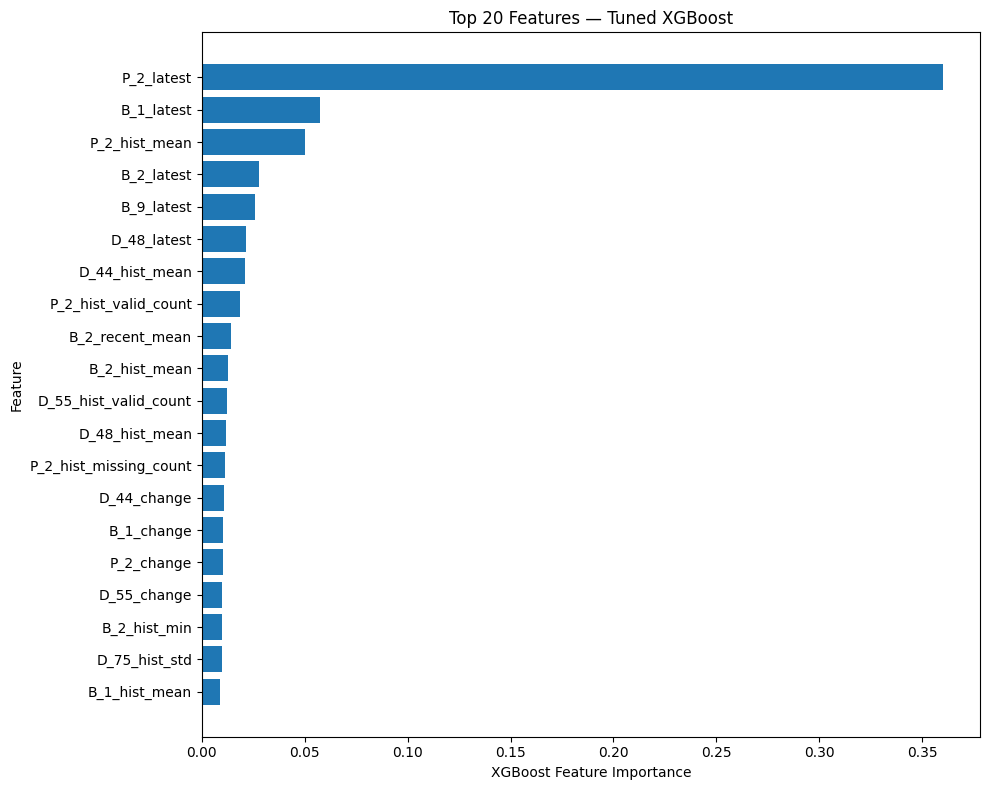

In [80]:
# ============================================================
# TOP 20 FEATURE IMPORTANCE PLOT
# ============================================================

top20 = feature_importance.head(20).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features — Tuned XGBoost")

plt.tight_layout()
plt.show()

**5.2 SHAP Analysis**

In [81]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [82]:
# Use a reproducible validation sample
SHAP_SAMPLE_SIZE = 2000

X_shap = X_valid_selected.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

SHAP sample shape: (2000, 70)
SHAP values shape: (2000, 70)


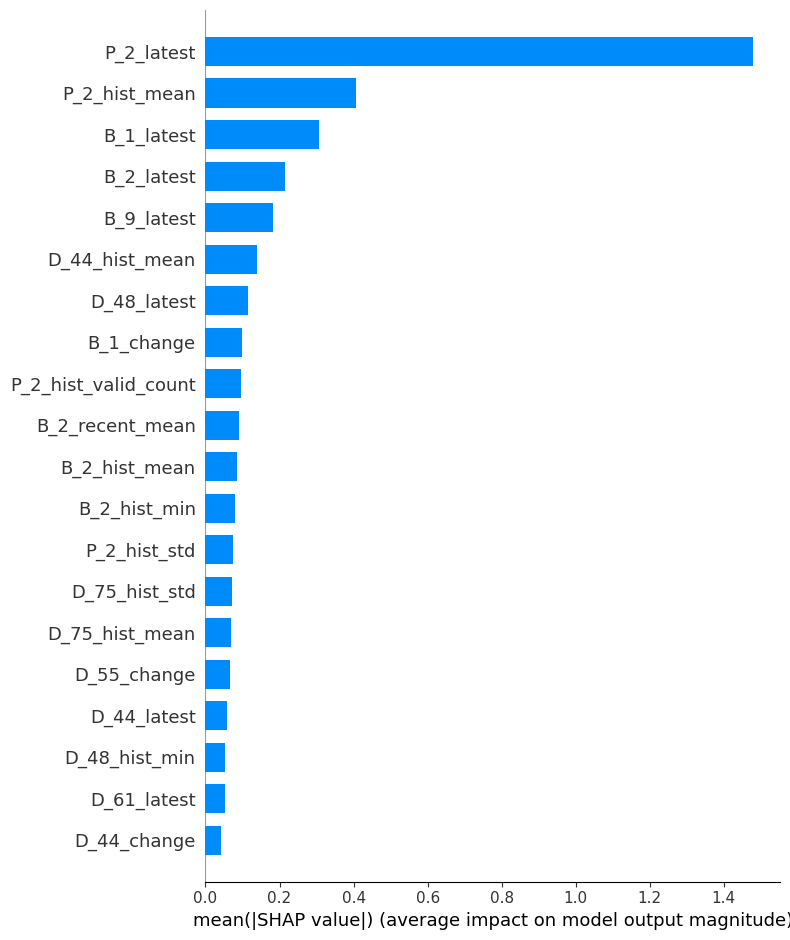

In [83]:
# SHAP — GLOBAL FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    plot_type="bar"
)

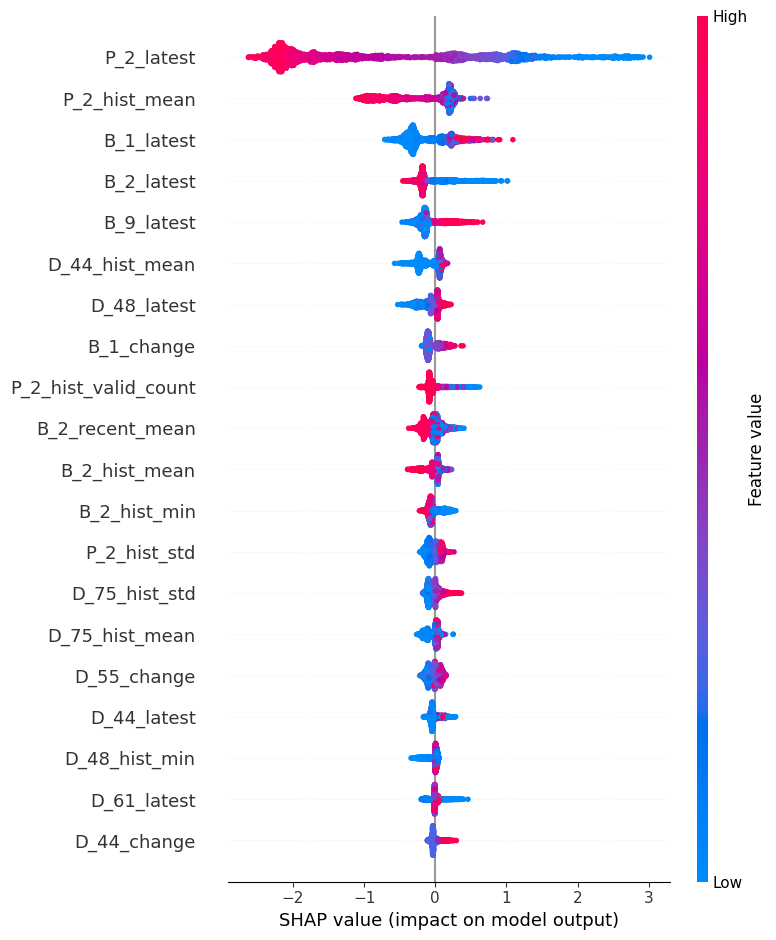

In [84]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)

What this second plot tells us

Unlike the XGBoost importance plot:

Position horizontally → whether the feature pushes prediction toward higher/lower default probability.
Color → whether the actual feature value is high or low.
Spread horizontally → magnitude of its impact.
Top-to-bottom → overall importance.

This is the plot we'll use for the business interpretation in your final project.
Red = high feature value
Blue = low feature value
SHAP value > 0 → pushes prediction toward default
SHAP value < 0 → pushes prediction toward non-default